# TODOs

include chosen and not chosen text

In [1]:
from shared.main import * 
from shared.nlp import *

# subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Schaefer100.pkl") 
# subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Tavares.pkl")
# subject_data = load_pickle("../../../analyses/lss_decision/subject_data_Tavares_and_striatum_spheres.pkl")

# building a choice representation that makes sense
I want it to vary across participants more


choice differences, embedded with various amounts of context

running mean and variance of choice differences

## between subject-correlations

In [ ]:
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# Basic helpers
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    return " ".join(str(x).replace("\n", " ").split()).strip()

def l2_normalize(X, axis=1, eps=1e-8):
    X = np.asarray(X, dtype=float)
    return X / (np.linalg.norm(X, axis=axis, keepdims=True) + eps)

def offdiag_values(S):
    S = np.asarray(S, dtype=float)
    return S[~np.eye(S.shape[0], dtype=bool)]

def embed_unique_texts(texts, batch_size=256):
    """
    Assumes get_sentence_embeddings(list_of_strings) exists.

    Returns
    -------
    emb_map : dict
        cleaned text -> unit-normalized embedding
    """
    unique_texts = (
        pd.Series(texts)
        .dropna()
        .map(clean_text)
        .loc[lambda s: s != ""]
        .drop_duplicates()
        .tolist()
    )

    if len(unique_texts) == 0:
        raise ValueError("No non-empty texts to embed.")

    chunks = []
    for i in range(0, len(unique_texts), batch_size):
        batch = unique_texts[i:i + batch_size]
        chunks.append(np.asarray(get_sentence_embeddings(batch), dtype=float))

    E = l2_normalize(np.vstack(chunks))
    return dict(zip(unique_texts, E))

def lookup_embeddings(texts, emb_map):
    return np.vstack([emb_map[clean_text(t)] for t in texts])

# ============================================================
# Load behavior
# ============================================================

def load_choice_df(
    incl_subs,
    *,
    trial_col=None,
    character_col="character_role_num",
    prevslide_col="prevslide_text",
    chosen_col="chosen_text",
    unchosen_col="unchosen_text",
):
    """
    Loads and stacks subject behavior.

    Internal standardized columns:
        sub_id
        character_role_num
        prevslide_text
        chosen_text
        unchosen_text
        _trial_order

    If trial_col=None, original row order before response filtering is used.
    """
    rows = []

    for sub_id in incl_subs:
        behavior = load_behavior(sub_id).copy()

        cols = [character_col, prevslide_col, chosen_col, unchosen_col]
        # decision_num is the stable key for task metadata such as dimension.
        if "decision_num" not in cols:
            cols.append("decision_num")
        if trial_col is not None:
            if trial_col not in cols:
                cols.append(trial_col)

        behavior = behavior[cols].copy()
        behavior["sub_id"] = sub_id

        # Preserve the task trial identity before removing missing responses.
        # Assigning 0..N after filtering makes a missing trial look like a
        # change in trial order and misaligns later trials across subjects.
        if trial_col is None:
            behavior["_trial_order"] = np.arange(len(behavior))
        else:
            if behavior[trial_col].isna().any():
                raise ValueError(f"Missing values in trial column {trial_col!r} for {sub_id}.")
            if behavior[trial_col].duplicated().any():
                raise ValueError(f"Duplicate values in trial column {trial_col!r} for {sub_id}.")
            behavior["_trial_order"] = behavior[trial_col].to_numpy()

        for col in [prevslide_col, chosen_col, unchosen_col]:
            behavior[col] = behavior[col].map(clean_text)

        behavior = behavior[
            (behavior[chosen_col] != "") &
            (behavior[unchosen_col] != "")
        ].copy()

        rows.append(behavior)

    df = pd.concat(rows, ignore_index=True)
    df = df.sort_values(["sub_id", "_trial_order"]).reset_index(drop=True)

    df = df.rename(
        columns={
            character_col: "character_role_num",
            prevslide_col: "prevslide_text",
            chosen_col: "chosen_text",
            unchosen_col: "unchosen_text",
        }
    )

    # Add the canonical task dimension by decision number. Do not infer this
    # from participant row position because missing responses create gaps.
    task_dimensions = decision_trials[["decision_num", "dimension"]].copy()
    if task_dimensions["decision_num"].duplicated().any():
        raise ValueError("decision_trials has duplicate decision_num values.")

    dimension_by_trial = task_dimensions.set_index("decision_num")["dimension"]
    df["dimension"] = df["decision_num"].map(dimension_by_trial)

    if df["dimension"].isna().any():
        missing_trials = sorted(df.loc[df["dimension"].isna(), "decision_num"].unique())
        raise ValueError(
            f"No task dimension found in decision_trials for decisions {missing_trials}."
        )

    return df

# ============================================================
# Representation name handling
# ============================================================

def canonical_rep_name(name):
    """
    Allows a few aliases from previous code.
    """
    aliases = {
        "diff_none": "choice_diff",
        "choice_diff_none": "choice_diff",
        "choice_diff_no_context": "choice_diff",

        "diff_local": "choice_diff_local",
        "choice_difference_local": "choice_diff_local",

        "diff_prev1": "choice_diff_prev1",
        "choice_diff_1_back": "choice_diff_prev1",

        "diff_history": "choice_diff_history",
        "choice_diff_total_history": "choice_diff_history",

        "choice_minus_running_mean": "surprise",
        "update": "surprise",
    }

    return aliases.get(name, name)

def parse_prev_n_rep(name, default_n_back=1):
    """
    Parses names like:
        choice_diff_prev1
        choice_diff_prev2
        choice_diff_prev10
        choice_diff_prevN

    Returns None if name is not a prev-N representation.
    """
    name = canonical_rep_name(name)

    if name == "choice_diff_prevN":
        return int(default_n_back)

    prefix = "choice_diff_prev"
    if name.startswith(prefix):
        suffix = name[len(prefix):]
        if suffix.isdigit():
            return int(suffix)

    return None

def rep_label(name):
    name = canonical_rep_name(name)

    n_back = parse_prev_n_rep(name)

    if name == "choice":
        return "Choice"

    if name == "choice_diff":
        return "Choice difference\nno context"

    if name == "choice_diff_local":
        return "Choice difference\nlocal context"

    if n_back is not None:
        return f"Choice difference\n{n_back} prior same-character choice(s)"

    if name == "choice_diff_history":
        return "Choice difference\ntotal same-character history"

    if name == "running_mean":
        return "Running mean\nrelationship prototype"

    if name == "running_variance":
        return "Running variance\nhistory heterogeneity"

    if name == "surprise":
        return "Choice - running mean\nupdate / surprise"

    return name

def validate_rep_names(rep_names, default_n_back=1):
    valid_fixed = {
        "choice",
        "choice_diff",
        "choice_diff_local",
        "choice_diff_history",
        "running_mean",
        "running_variance",
        "surprise",
    }

    out = []

    for name in rep_names:
        name = canonical_rep_name(name)

        if name in valid_fixed:
            out.append(name)
            continue

        if parse_prev_n_rep(name, default_n_back=default_n_back) is not None:
            out.append(name)
            continue

        raise ValueError(
            f"Unknown representation: {name}. Supported names include: "
            "'choice', 'choice_diff', 'choice_diff_local', "
            "'choice_diff_prev1', 'choice_diff_prev2', ..., "
            "'choice_diff_history', 'running_mean', 'running_variance', 'surprise'."
        )

    return out

# ============================================================
# Prompt construction
# ============================================================

def build_prompt_df(
    df,
    rep_names,
    *,
    default_n_back=1,
):
    """
    Builds prompt columns needed for the requested representations.

    Context definitions:
        choice / choice_diff:
            option text only

        choice_diff_local:
            current scene + current option

        choice_diff_prevN:
            current scene + previous N same-character chosen choices + current option

        choice_diff_history:
            current scene + all previous same-character chosen choices + current option
    """
    rep_names = validate_rep_names(rep_names, default_n_back=default_n_back)
    out = df.copy().reset_index(drop=True)

    def add_history_column(history_k, col_name):
        history = defaultdict(list)
        hist_text = {}

        for idx, row in out.sort_values(["sub_id", "_trial_order"]).iterrows():
            key = (row["sub_id"], row["character_role_num"])
            prior = history[key]

            if history_k is None:
                use_prior = prior
            else:
                use_prior = prior[-int(history_k):]

            if len(use_prior) == 0:
                hist_text[idx] = "none"
            else:
                hist_text[idx] = " | ".join(
                    f"{i + 1}. {txt}" for i, txt in enumerate(use_prior)
                )

            # Add current choice only after making the current trial's history.
            history[key].append(clean_text(row["chosen_text"]))

        out[col_name] = out.index.map(hist_text)

    def make_context_prompt(row, option_text, history_col=None):
        pieces = [
            f"Current scene: {clean_text(row['prevslide_text'])}",
        ]

        if history_col is not None:
            pieces.append(
                "Previous choices with this character: "
                f"{clean_text(row[history_col])}"
            )

        pieces.append(f"Current option: {clean_text(option_text)}")

        return "\n".join(pieces)

    # Always build no-context prompts because running-history variables
    # are computed from no-context choice-difference vectors.
    out["_choice_chosen_prompt"] = out["chosen_text"]
    out["_choice_unchosen_prompt"] = out["unchosen_text"]

    out["_choice_diff_chosen_prompt"] = out["chosen_text"]
    out["_choice_diff_unchosen_prompt"] = out["unchosen_text"]

    # Local current-scene context.
    if "choice_diff_local" in rep_names:
        out["_choice_diff_local_chosen_prompt"] = out.apply(
            lambda r: make_context_prompt(r, r["chosen_text"], history_col=None),
            axis=1,
        )
        out["_choice_diff_local_unchosen_prompt"] = out.apply(
            lambda r: make_context_prompt(r, r["unchosen_text"], history_col=None),
            axis=1,
        )

    # Previous-N same-character histories.
    prev_ns = sorted({
        parse_prev_n_rep(name, default_n_back=default_n_back)
        for name in rep_names
        if parse_prev_n_rep(name, default_n_back=default_n_back) is not None
    })

    for n_back in prev_ns:
        hist_col = f"_same_character_history_prev{n_back}"
        add_history_column(history_k=n_back, col_name=hist_col)

        out[f"_choice_diff_prev{n_back}_chosen_prompt"] = out.apply(
            lambda r, hc=hist_col: make_context_prompt(r, r["chosen_text"], history_col=hc),
            axis=1,
        )
        out[f"_choice_diff_prev{n_back}_unchosen_prompt"] = out.apply(
            lambda r, hc=hist_col: make_context_prompt(r, r["unchosen_text"], history_col=hc),
            axis=1,
        )

    # Total same-character history.
    if "choice_diff_history" in rep_names:
        hist_col = "_same_character_history_all"
        add_history_column(history_k=None, col_name=hist_col)

        out["_choice_diff_history_chosen_prompt"] = out.apply(
            lambda r: make_context_prompt(r, r["chosen_text"], history_col=hist_col),
            axis=1,
        )
        out["_choice_diff_history_unchosen_prompt"] = out.apply(
            lambda r: make_context_prompt(r, r["unchosen_text"], history_col=hist_col),
            axis=1,
        )

    return out

def prompt_cols_for_rep(name, *, default_n_back=1):
    """
    Returns chosen/unchosen prompt columns for prompt-based representations.
    Returns None for running-history representations.
    """
    name = canonical_rep_name(name)

    if name == "choice":
        return "_choice_chosen_prompt", "_choice_unchosen_prompt"

    if name == "choice_diff":
        return "_choice_diff_chosen_prompt", "_choice_diff_unchosen_prompt"

    if name == "choice_diff_local":
        return "_choice_diff_local_chosen_prompt", "_choice_diff_local_unchosen_prompt"

    n_back = parse_prev_n_rep(name, default_n_back=default_n_back)
    if n_back is not None:
        return (
            f"_choice_diff_prev{n_back}_chosen_prompt",
            f"_choice_diff_prev{n_back}_unchosen_prompt",
        )

    if name == "choice_diff_history":
        return (
            "_choice_diff_history_chosen_prompt",
            "_choice_diff_history_unchosen_prompt",
        )

    return None


# ============================================================
# Running-history functions
# ============================================================

def running_mean_vectors(V):
    """
    Prior running mean.

    V[t] is current choice-difference vector.
    output[t] = mean(V[:t])

    For t=0, output[0] = 0 because there is no prior history.
    """
    V = np.asarray(V, dtype=float)

    if V.ndim != 2:
        raise ValueError("V must be 2D: n_trials x n_features.")

    n, dim = V.shape
    out = np.zeros((n, dim))

    if n <= 1:
        return out

    csum = np.cumsum(V, axis=0)
    out[1:] = csum[:-1] / np.arange(1, n)[:, None]

    return out

def running_variance_values(V, *, min_prior=2):
    """
    Prior directional/spherical variance.

    This is the high-dimensional analogue of circular variance:

        variance[t] = 1 - ||mean(V[:t])||

    assuming V contains unit-normalized choice-difference vectors.

    Low value:
        prior choices are directionally consistent.

    High value:
        prior choices are directionally heterogeneous.

    Values with fewer than min_prior previous trials are set to NaN.
    """
    V = l2_normalize(V)

    M = running_mean_vectors(V)
    R = np.linalg.norm(M, axis=1)

    var = 1.0 - R

    prior_n = np.arange(len(V))
    var[prior_n < min_prior] = np.nan

    return var


def choice_minus_running_mean_vectors(V):
    """
    Current choice-difference vector minus prior running mean.

    output[t] = V[t] - mean(V[:t])

    Interpretable as update, deviation, surprise, or steering direction.
    """
    V = np.asarray(V, dtype=float)

    if V.ndim != 2:
        raise ValueError("V must be 2D: n_trials x n_features.")

    return V - running_mean_vectors(V)


def compute_character_history_stats(
    df,
    choice_diff_vecs,
    *,
    variance_min_prior=2,
):
    """
    Computes running statistics separately within each subject-character history.

    Important:
        These are prior-only. The current trial is not included in its own history.
    """
    df = df.reset_index(drop=True).copy()

    # Directional variance assumes unit vectors.
    V = l2_normalize(choice_diff_vecs)

    n_trials, dim = V.shape

    running_mean = np.zeros((n_trials, dim))
    running_variance = np.full(n_trials, np.nan)
    surprise = np.zeros((n_trials, dim))
    prior_n = np.zeros(n_trials, dtype=int)

    for _, g in df.groupby(["sub_id", "character_role_num"], sort=False):
        idx = g.sort_values("_trial_order").index.to_numpy()
        Vg = V[idx]

        running_mean[idx] = running_mean_vectors(Vg)
        running_variance[idx] = running_variance_values(
            Vg,
            min_prior=variance_min_prior,
        )
        surprise[idx] = choice_minus_running_mean_vectors(Vg)
        prior_n[idx] = np.arange(len(idx))

    return {
        "running_mean": running_mean,
        "running_variance": running_variance,
        "surprise": surprise,
        "prior_n": prior_n,
    }


# ============================================================
# Aggregation to subject-level representations
# ============================================================

def aggregate_vector_by_character(
    df,
    trial_vecs,
    *,
    sub_ids,
    valid_mask=None,
    normalize_subject_reps=True,
):
    """
    Vector-valued representation.

    Participant representation:
        concatenate character-wise mean vectors.
    """
    X = np.asarray(trial_vecs, dtype=float)

    if X.ndim != 2:
        raise ValueError("trial_vecs must be 2D: n_trials x n_features.")

    if valid_mask is None:
        valid_mask = np.ones(len(df), dtype=bool)
    else:
        valid_mask = np.asarray(valid_mask, dtype=bool)

    chars = sorted(df["character_role_num"].dropna().unique().tolist(), key=str)
    dim = X.shape[1]

    reps = []

    for sub_id in sub_ids:
        parts = []

        for c in chars:
            idx = (
                (df["sub_id"].values == sub_id) &
                (df["character_role_num"].values == c) &
                valid_mask
            )

            if idx.sum() == 0:
                parts.append(np.zeros(dim))
            else:
                parts.append(X[idx].mean(axis=0))

        reps.append(np.concatenate(parts))

    reps = np.vstack(reps)

    if normalize_subject_reps:
        reps = l2_normalize(reps)

    return reps


def aggregate_scalar_sequence_by_character(
    df,
    values,
    *,
    sub_ids,
    valid_mask=None,
):
    """
    Scalar-valued representation, used for running variance.

    Participant representation:
        concatenate character-specific scalar trajectories.

    This is preferable to one mean variance per character because it preserves
    the time-course of consistency/heterogeneity within each relationship.
    """
    x = np.asarray(values, dtype=float)

    if x.ndim != 1:
        raise ValueError("values must be 1D: n_trials.")

    if valid_mask is None:
        valid_mask = np.isfinite(x)
    else:
        valid_mask = np.asarray(valid_mask, dtype=bool) & np.isfinite(x)

    chars = sorted(df["character_role_num"].dropna().unique().tolist(), key=str)

    max_len_by_char = {}
    for c in chars:
        lengths = []
        for sub_id in sub_ids:
            idx = (
                (df["sub_id"].values == sub_id) &
                (df["character_role_num"].values == c) &
                valid_mask
            )
            lengths.append(idx.sum())

        max_len_by_char[c] = max(lengths)

    if sum(max_len_by_char.values()) == 0:
        raise ValueError("No valid scalar history values to aggregate.")

    reps = []

    for sub_id in sub_ids:
        parts = []

        for c in chars:
            max_len = max_len_by_char[c]
            if max_len == 0:
                continue

            idx = (
                (df["sub_id"].values == sub_id) &
                (df["character_role_num"].values == c) &
                valid_mask
            )

            sub_df = df.loc[idx].sort_values("_trial_order")
            vals = x[sub_df.index.to_numpy()]

            arr = np.full(max_len, np.nan)
            arr[:len(vals)] = vals
            parts.append(arr)

        reps.append(np.concatenate(parts))

    reps = np.vstack(reps)

    # Mean-impute missing columns.
    col_mean = np.nanmean(reps, axis=0)
    col_mean = np.where(np.isfinite(col_mean), col_mean, 0.0)

    missing = ~np.isfinite(reps)
    if missing.any():
        reps[missing] = np.take(col_mean, np.where(missing)[1])

    return reps


# ============================================================
# Main representation computation
# ============================================================

def compute_choice_subject_representations(
    incl_subs,
    rep_names,
    *,
    trial_col=None,
    character_col="character_role_num",
    prevslide_col="prevslide_text",
    chosen_col="chosen_text",
    unchosen_col="unchosen_text",
    default_n_back=1,
    normalize_trial_diffs=True,
    variance_min_prior=2,
    batch_size=256,
):
    """
    Computes subject-level representations for selected choice models.

    Supported rep_names:
        "choice"
        "choice_diff"
        "choice_diff_local"
        "choice_diff_prev1"
        "choice_diff_prev2"
        ...
        "choice_diff_history"
        "running_mean"
        "running_variance"
        "surprise"

    Notes
    -----
    running_mean, running_variance, and surprise are computed from the
    no-context choice-difference vectors:

        embedding(chosen_text) - embedding(unchosen_text)

    within each subject-character history.
    """
    rep_names = validate_rep_names(rep_names, default_n_back=default_n_back)

    df = load_choice_df(
        incl_subs,
        trial_col=trial_col,
        character_col=character_col,
        prevslide_col=prevslide_col,
        chosen_col=chosen_col,
        unchosen_col=unchosen_col,
    )

    sub_ids = list(incl_subs)

    prompt_df = build_prompt_df(
        df,
        rep_names,
        default_n_back=default_n_back,
    )

    # Need no-context choice-difference prompts whenever running-history
    # representations are requested.
    needs_history_base = any(
        name in {"running_mean", "running_variance", "surprise"}
        for name in rep_names
    )

    prompt_rep_names = [
        name for name in rep_names
        if prompt_cols_for_rep(name, default_n_back=default_n_back) is not None
    ]

    if needs_history_base and "choice_diff" not in prompt_rep_names:
        prompt_rep_names = ["choice_diff"] + prompt_rep_names

    # Collect all prompt texts needed for one embedding pass.
    prompt_cols = []
    for name in prompt_rep_names:
        cols = prompt_cols_for_rep(name, default_n_back=default_n_back)
        prompt_cols.extend(list(cols))

    prompt_cols = list(dict.fromkeys(prompt_cols))

    all_prompts = []
    for col in prompt_cols:
        all_prompts.extend(prompt_df[col].tolist())

    emb_map = embed_unique_texts(all_prompts, batch_size=batch_size)

    def get_prompt_embeddings(name):
        chosen_prompt_col, unchosen_prompt_col = prompt_cols_for_rep(
            name,
            default_n_back=default_n_back,
        )

        E_chosen = lookup_embeddings(prompt_df[chosen_prompt_col], emb_map)
        E_unchosen = lookup_embeddings(prompt_df[unchosen_prompt_col], emb_map)

        return E_chosen, E_unchosen

    trial_vectors = {}
    representations = {}
    metadata = {}

    # Prompt-based representations.
    for name in rep_names:
        if name in {"running_mean", "running_variance", "surprise"}:
            continue

        E_chosen, E_unchosen = get_prompt_embeddings(name)

        if name == "choice":
            trial_vecs = E_chosen
            sim_type = "cosine"
        else:
            trial_vecs = E_chosen - E_unchosen
            if normalize_trial_diffs:
                trial_vecs = l2_normalize(trial_vecs)
            sim_type = "cosine"

        trial_vectors[name] = trial_vecs

        representations[name] = aggregate_vector_by_character(
            prompt_df,
            trial_vecs,
            sub_ids=sub_ids,
            valid_mask=None,
            normalize_subject_reps=True,
        )

        metadata[name] = {
            "label": rep_label(name),
            "kind": "vector",
            "similarity": sim_type,
        }

    # Running-history representations.
    if needs_history_base:
        E_chosen_base, E_unchosen_base = get_prompt_embeddings("choice_diff")
        base_diff_vecs = E_chosen_base - E_unchosen_base

        if normalize_trial_diffs:
            base_diff_vecs = l2_normalize(base_diff_vecs)

        trial_vectors["choice_diff_base_for_history"] = base_diff_vecs

        history_stats = compute_character_history_stats(
            prompt_df,
            base_diff_vecs,
            variance_min_prior=variance_min_prior,
        )

        valid_mean_and_surprise = history_stats["prior_n"] >= 1
        valid_variance = np.isfinite(history_stats["running_variance"])

        if "running_mean" in rep_names:
            trial_vectors["running_mean"] = history_stats["running_mean"]

            representations["running_mean"] = aggregate_vector_by_character(
                prompt_df,
                history_stats["running_mean"],
                sub_ids=sub_ids,
                valid_mask=valid_mean_and_surprise,
                normalize_subject_reps=True,
            )

            metadata["running_mean"] = {
                "label": rep_label("running_mean"),
                "kind": "vector",
                "similarity": "cosine",
            }

        if "running_variance" in rep_names:
            trial_vectors["running_variance"] = history_stats["running_variance"]

            representations["running_variance"] = aggregate_scalar_sequence_by_character(
                prompt_df,
                history_stats["running_variance"],
                sub_ids=sub_ids,
                valid_mask=valid_variance,
            )

            metadata["running_variance"] = {
                "label": rep_label("running_variance"),
                "kind": "scalar_sequence",
                "similarity": "rbf",
            }

        if "surprise" in rep_names:
            trial_vectors["surprise"] = history_stats["surprise"]

            representations["surprise"] = aggregate_vector_by_character(
                prompt_df,
                history_stats["surprise"],
                sub_ids=sub_ids,
                valid_mask=valid_mean_and_surprise,
                normalize_subject_reps=True,
            )

            metadata["surprise"] = {
                "label": rep_label("surprise"),
                "kind": "vector",
                "similarity": "cosine",
            }

    rep_summary = pd.DataFrame([
        {
            "representation": name,
            "label": metadata[name]["label"].replace("\n", " "),
            "kind": metadata[name]["kind"],
            "similarity": metadata[name]["similarity"],
            "shape": representations[name].shape,
        }
        for name in rep_names
    ])

    return {
        "df": prompt_df,
        "sub_ids": sub_ids,
        "rep_names": rep_names,
        "representations": representations,
        "trial_vectors": trial_vectors,
        "metadata": metadata,
        "rep_summary": rep_summary,
    }


# ============================================================
# Similarity matrices
# ============================================================

def compute_subject_similarity_matrices(
    rep_out,
    *,
    rep_names=None,
):
    """
    Computes across-subject similarity matrices from subject-level representations.

    Similarity type:
        cosine for vector representations
        RBF similarity for running_variance scalar trajectories
    """
    if rep_names is None:
        rep_names = rep_out["rep_names"]

    def zscore_columns(X, eps=1e-8):
        X = np.asarray(X, dtype=float)
        mu = np.nanmean(X, axis=0, keepdims=True)
        sd = np.nanstd(X, axis=0, keepdims=True)
        sd = np.where(sd < eps, 1.0, sd)
        return (X - mu) / sd

    def rbf_similarity(X, eps=1e-8):
        X = zscore_columns(X)
        D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=-1))

        off = D[~np.eye(D.shape[0], dtype=bool)]
        off = off[np.isfinite(off) & (off > eps)]

        sigma = np.median(off) if len(off) else 1.0
        if not np.isfinite(sigma) or sigma <= eps:
            sigma = 1.0

        return np.exp(-(D ** 2) / (2 * sigma ** 2))

    matrices = {}
    rows = []

    for name in rep_names:
        X = np.asarray(rep_out["representations"][name], dtype=float)
        sim_type = rep_out["metadata"][name]["similarity"]

        if sim_type == "cosine":
            S = cosine_similarity(l2_normalize(X))
        elif sim_type == "rbf":
            S = rbf_similarity(X)
        else:
            raise ValueError(f"Unknown similarity type for {name}: {sim_type}")

        matrices[name] = S

        off = offdiag_values(S)
        rows.append({
            "representation": name,
            "label": rep_out["metadata"][name]["label"].replace("\n", " "),
            "similarity": sim_type,
            "offdiag_mean": float(np.nanmean(off)),
            "offdiag_sd": float(np.nanstd(off)),
            "min": float(np.nanmin(S)),
            "max": float(np.nanmax(S)),
        })

    return {
        "matrices": matrices,
        "summary": pd.DataFrame(rows),
        "rep_names": list(rep_names),
        "metadata": rep_out["metadata"],
        "sub_ids": rep_out["sub_ids"],
    }


# ============================================================
# Plotting
# ============================================================

def plot_subject_similarity_matrices(
    sim_out,
    *,
    rep_names=None,
    panel_width=4.2,
    panel_height=3.8,
    show_sub_ids=False,
    common_scale="cosine",
):
    """
    Plots all requested across-subject similarity matrices in one row.

    common_scale:
        None      -> each panel gets its own scale
        "all"     -> all panels share one scale
        "cosine"  -> cosine panels share one scale; RBF panels use own scale
    """
    if rep_names is None:
        rep_names = sim_out["rep_names"]

    matrices = sim_out["matrices"]
    metadata = sim_out["metadata"]
    sub_ids = sim_out["sub_ids"]

    n = len(rep_names)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(panel_width * n, panel_height),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    if common_scale == "all":
        global_vmin = min(np.nanmin(matrices[name]) for name in rep_names)
        global_vmax = max(np.nanmax(matrices[name]) for name in rep_names)
    else:
        global_vmin, global_vmax = None, None

    if common_scale == "cosine":
        cosine_names = [
            name for name in rep_names
            if metadata[name]["similarity"] == "cosine"
        ]

        if len(cosine_names) > 0:
            cosine_vmin = min(np.nanmin(matrices[name]) for name in cosine_names)
            cosine_vmax = max(np.nanmax(matrices[name]) for name in cosine_names)
        else:
            cosine_vmin, cosine_vmax = None, None
    else:
        cosine_vmin, cosine_vmax = None, None

    for i, (ax, name) in enumerate(zip(axes, rep_names)):
        S = matrices[name]
        sim_type = metadata[name]["similarity"]
        label = metadata[name]["label"]

        if common_scale == "all":
            vmin, vmax = global_vmin, global_vmax
        elif common_scale == "cosine" and sim_type == "cosine":
            vmin, vmax = cosine_vmin, cosine_vmax
        else:
            vmin, vmax = None, None

        im = ax.imshow(S, vmin=vmin, vmax=vmax, aspect="auto")

        ax.set_title(f"{label}\n{sim_type} similarity", fontsize=10)
        ax.set_xlabel("Participant")

        if i == 0:
            ax.set_ylabel("Participant")
        else:
            ax.set_ylabel("")

        if show_sub_ids and len(sub_ids) <= 30:
            ax.set_xticks(np.arange(len(sub_ids)))
            ax.set_yticks(np.arange(len(sub_ids)))
            ax.set_xticklabels(sub_ids, rotation=90, fontsize=5)
            ax.set_yticklabels(sub_ids, fontsize=5)
        else:
            ax.set_xticks([])
            ax.set_yticks([])

        off = offdiag_values(S)
        ax.text(
            0.02,
            0.98,
            f"offdiag mean={np.nanmean(off):.3f}\n"
            f"offdiag sd={np.nanstd(off):.3f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
        )

        fig.colorbar(im, ax=ax, shrink=0.78)

    plt.show()


# ============================================================
# Convenience runner
# ============================================================

def run_choice_representation_analysis(
    incl_subs,
    rep_names,
    *,
    trial_col=None,
    character_col="character_role_num",
    prevslide_col="prevslide_text",
    chosen_col="chosen_text",
    unchosen_col="unchosen_text",
    default_n_back=1,
    normalize_trial_diffs=True,
    variance_min_prior=2,
    batch_size=256,
    plot=True,
    common_scale="cosine",
    panel_width=4.2,
    panel_height=3.8,
    show_sub_ids=False,
):
    """
    Full pipeline:
        1. compute subject-level representations
        2. compute across-subject similarity matrices
        3. optionally plot all matrices in one row
    """
    rep_out = compute_choice_subject_representations(
        incl_subs,
        rep_names,
        trial_col=trial_col,
        character_col=character_col,
        prevslide_col=prevslide_col,
        chosen_col=chosen_col,
        unchosen_col=unchosen_col,
        default_n_back=default_n_back,
        normalize_trial_diffs=normalize_trial_diffs,
        variance_min_prior=variance_min_prior,
        batch_size=batch_size,
    )

    sim_out = compute_subject_similarity_matrices(
        rep_out,
        rep_names=rep_out["rep_names"],
    )

    if plot:
        plot_subject_similarity_matrices(
            sim_out,
            rep_names=rep_out["rep_names"],
            panel_width=panel_width,
            panel_height=panel_height,
            show_sub_ids=show_sub_ids,
            common_scale=common_scale,
        )

    out = {
        **rep_out,
        "matrices": sim_out["matrices"],
        "similarity_summary": sim_out["summary"],
    }

    return out


# ============================================================
# Run
# ============================================================

REPRESENTATIONS_TO_RUN = [
    "choice",
    "choice_diff",
    "choice_diff_local",
    "choice_diff_prev1",      # change to choice_diff_prev2, choice_diff_prev3, etc.
    "running_mean",
    "running_variance",
    "surprise",
]

out_choice_reps = run_choice_representation_analysis(
    incl_subs,
    REPRESENTATIONS_TO_RUN,
    trial_col="decision_num",  # stable task-trial identifier
    character_col="character_role_num",
    prevslide_col="prevslide_text",
    chosen_col="chosen_text",
    unchosen_col="unchosen_text",
    default_n_back=1,
    normalize_trial_diffs=True,
    variance_min_prior=2,
    batch_size=256,
    plot=True,
    common_scale="cosine",
    panel_width=4.2,
    panel_height=3.8,
    show_sub_ids=False,
)

# Subject-level representations are here:
# out_choice_reps["representations"]["choice"]
# out_choice_reps["representations"]["choice_diff"]
# out_choice_reps["representations"]["choice_diff_local"]
# out_choice_reps["representations"]["choice_diff_prev1"]
# out_choice_reps["representations"]["running_mean"]
# out_choice_reps["representations"]["running_variance"]
# out_choice_reps["representations"]["surprise"]

   representation                                              label  mean_r  median_r  fisher_mean_r  sd_r  n_subject_pairs
           choice                                             Choice   0.770     0.772          0.776 0.057             3081
      choice_diff                       Choice difference no context   0.063     0.039          0.063 0.088             3081
choice_diff_local                    Choice difference local context   0.058     0.036          0.059 0.083             3081
choice_diff_prev1 Choice difference 1 prior same-character choice(s)   0.061     0.038          0.061 0.084             3081
     running_mean                Running mean relationship prototype   0.492     0.491          0.499 0.097             3081
 running_variance             Running variance history heterogeneity   0.807     0.835          0.829 0.106             3081
         surprise            Choice - running mean update / surprise   0.060     0.040          0.060 0.090             3081


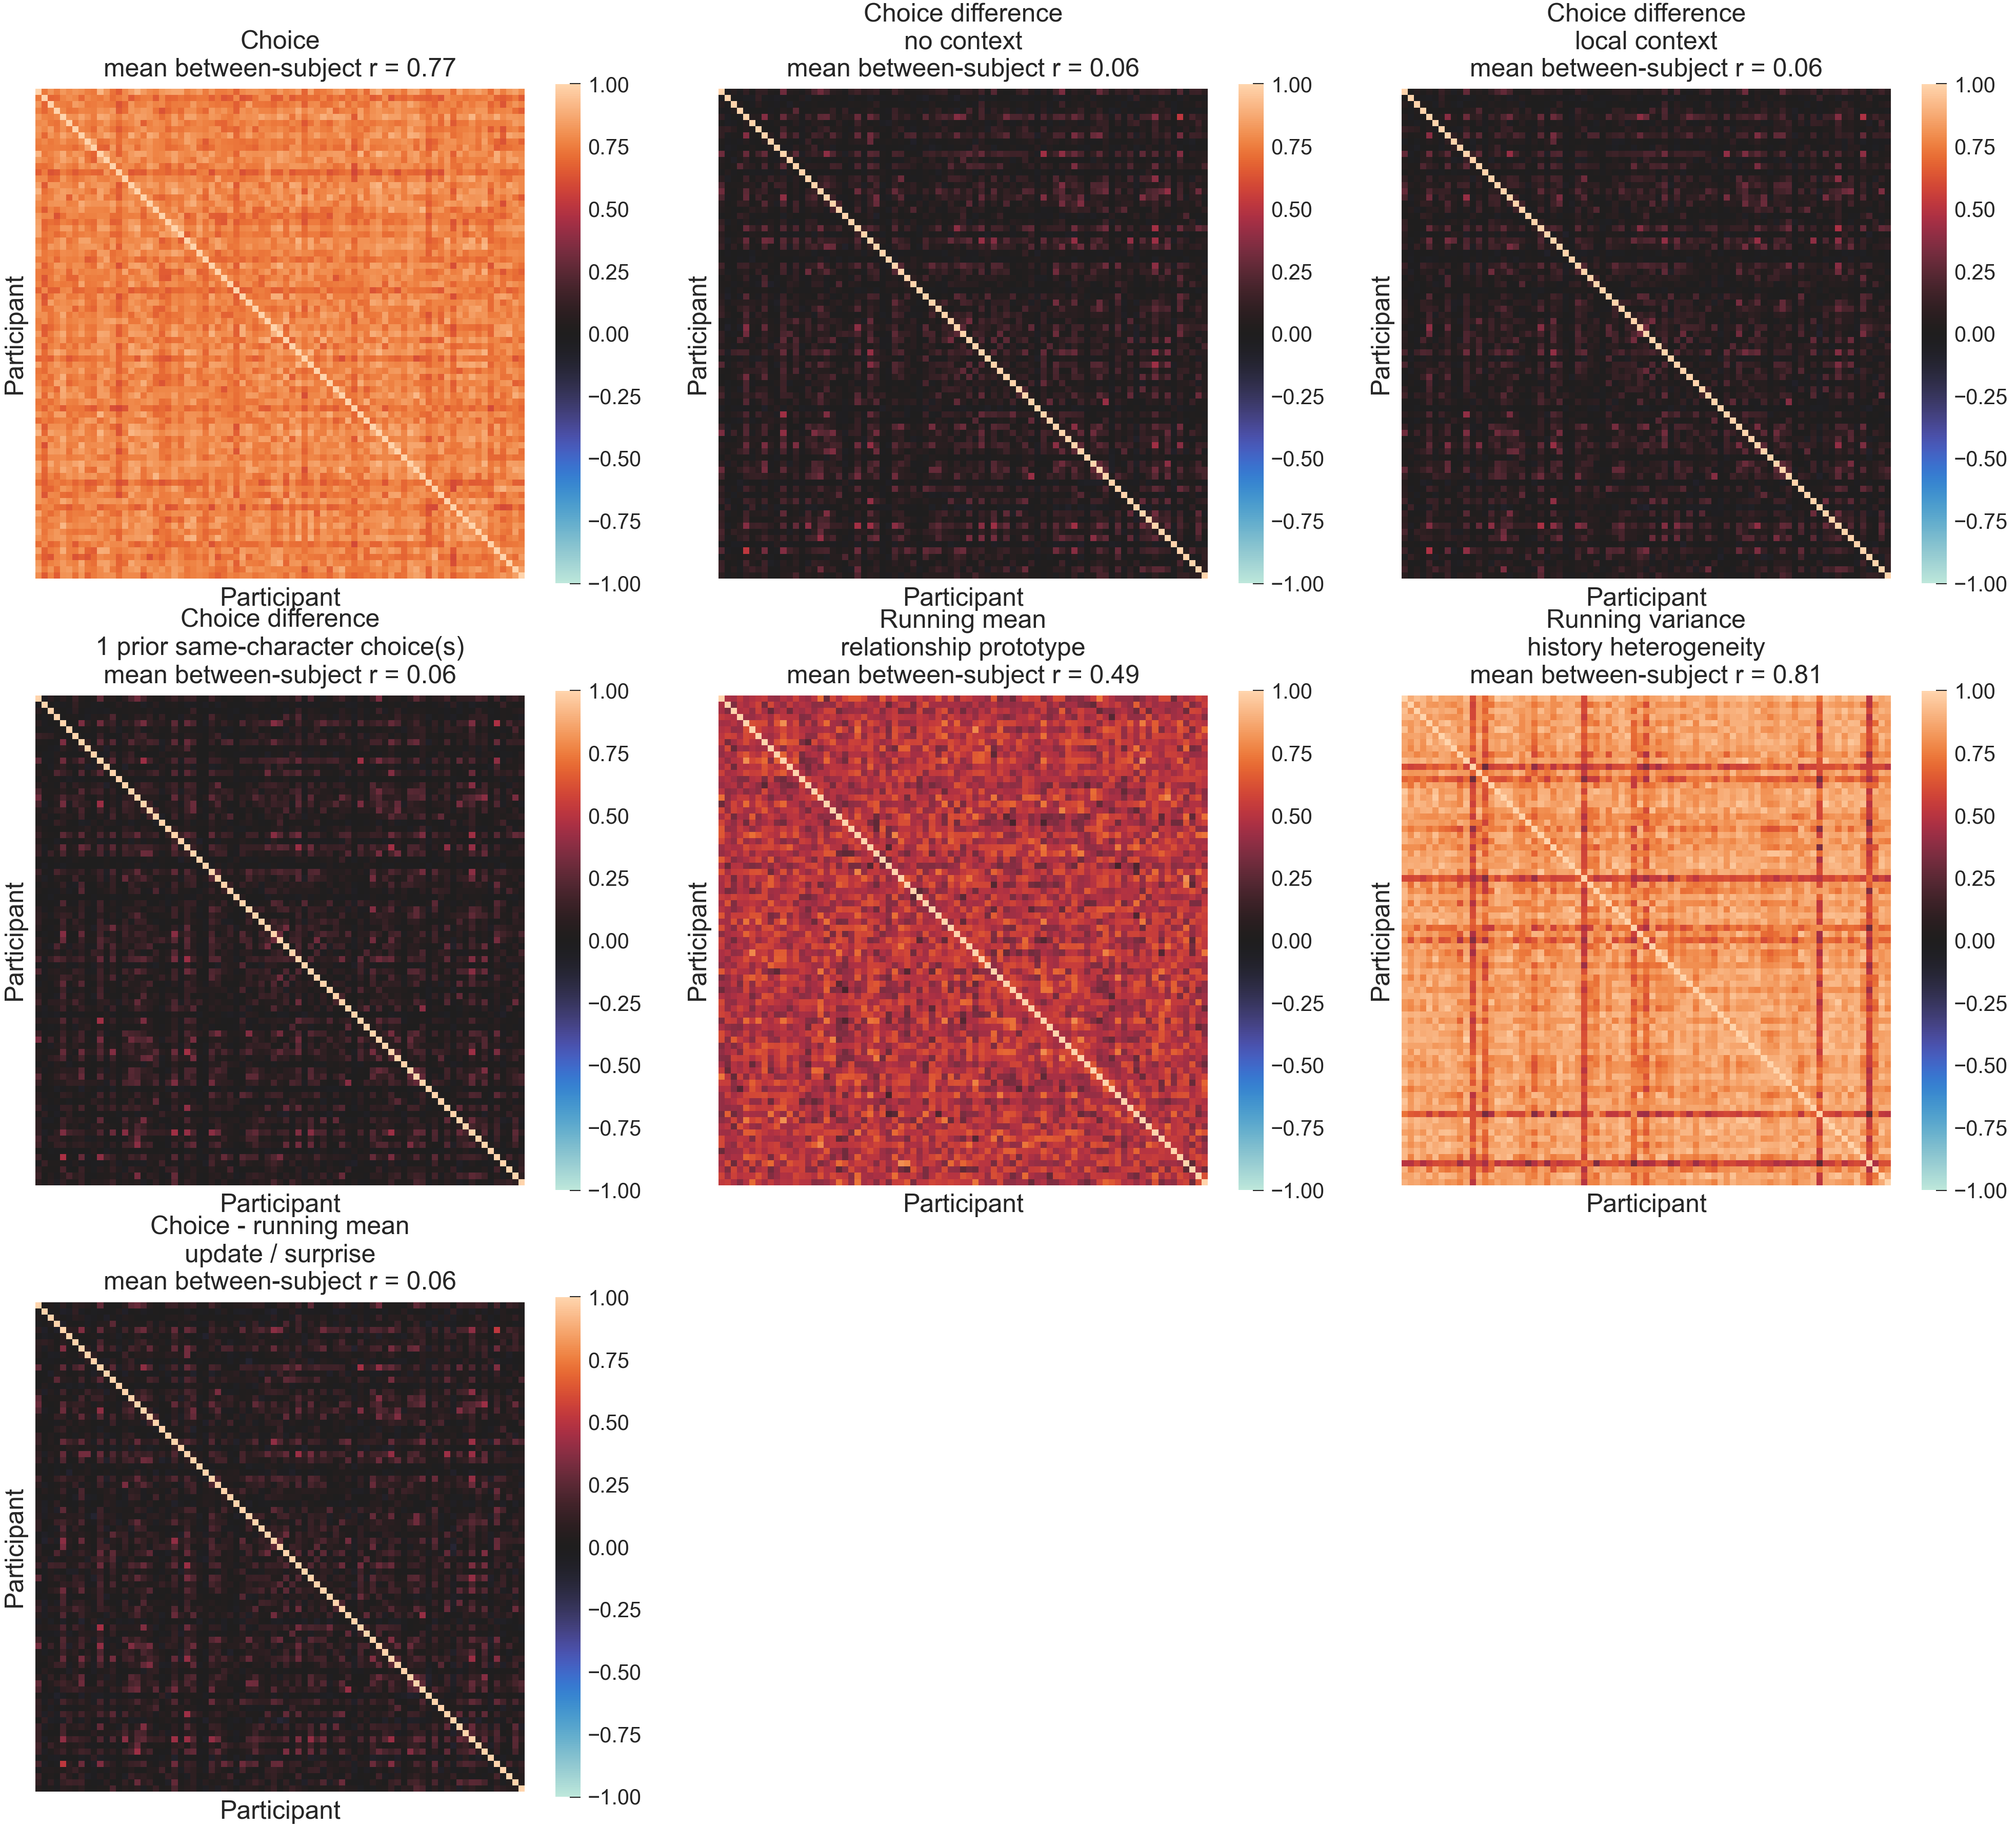

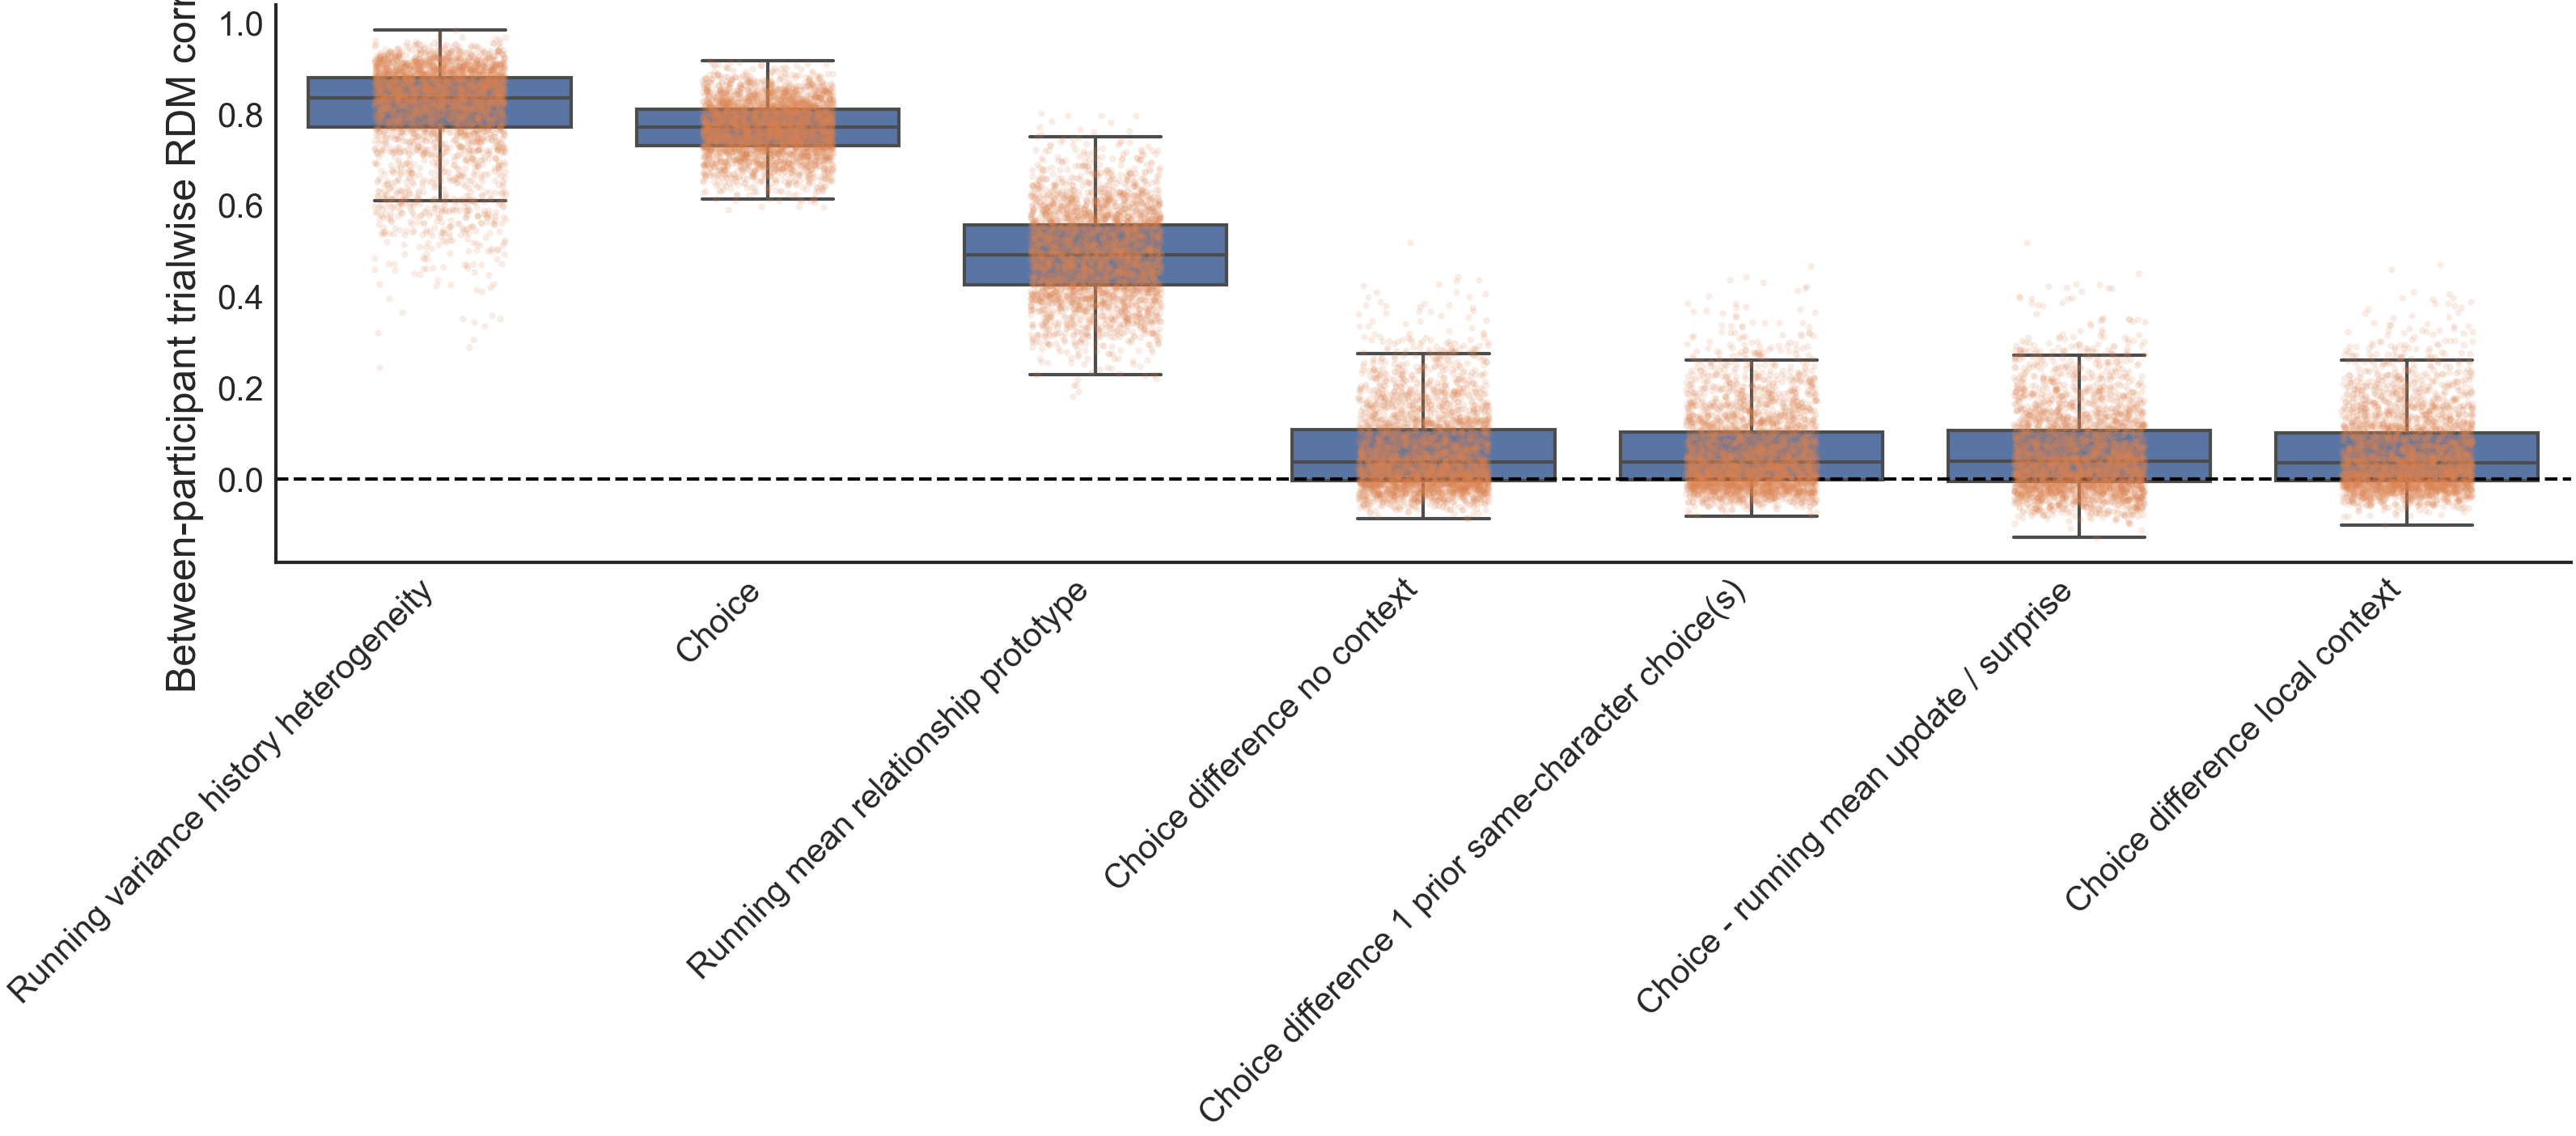

In [5]:
from scipy.stats import rankdata


# ============================================================
# 1. Make one participant's trial-by-trial RDM
# ============================================================

def make_trial_rdm_vector(X, valid_rows=None):
    """
    Vector representations:
        cosine distance between trials

    Scalar representations:
        absolute difference between trials

    Returns the upper triangle of the trial-by-trial RDM.
    """
    X = np.asarray(X, float)
    n_trials = len(X)

    if valid_rows is None:
        valid_rows = np.ones(n_trials, dtype=bool)
    else:
        valid_rows = np.asarray(valid_rows, bool)

    # Scalar representation, e.g. running variance
    if X.ndim == 1:
        valid_rows &= np.isfinite(X)

        D = np.abs(X[:, None] - X[None, :])
        valid_pairs = valid_rows[:, None] & valid_rows[None, :]
        D[~valid_pairs] = np.nan

    # Vector representation
    else:
        valid_rows &= np.isfinite(X).all(axis=1)

        norms = np.linalg.norm(X, axis=1)
        valid_rows &= norms > 1e-8

        U = np.full_like(X, np.nan)
        U[valid_rows] = X[valid_rows] / norms[valid_rows, None]

        similarity = U @ U.T
        D = 1 - np.clip(similarity, -1, 1)

        valid_pairs = valid_rows[:, None] & valid_rows[None, :]
        D[~valid_pairs] = np.nan

    iu = np.triu_indices(n_trials, k=1)
    return D[iu]


def correlation_statistic(x, y, *, method="spearman", eps=1e-12):
    """Correlation coefficient only; avoids SciPy's unused p-value work."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if method == "spearman":
        x = rankdata(x)
        y = rankdata(y)
    elif method != "pearson":
        raise ValueError("method must be 'spearman' or 'pearson'")

    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt(np.dot(x, x) * np.dot(y, y))
    if not np.isfinite(denom) or denom <= eps:
        return np.nan
    return float(np.dot(x, y) / denom)


# ============================================================
# 2. Correlate trialwise RDMs between participants
# ============================================================

def analyze_between_subject_rdm_similarity(
    out_choice_reps,
    rep_names=None,
    method="spearman",
):
    df = out_choice_reps["df"].reset_index(drop=True)

    if rep_names is None:
        rep_names = out_choice_reps["rep_names"]

    sub_ids = out_choice_reps["sub_ids"]

    # Number of previous retained choices with the same character.
    # Compute this explicitly in task order rather than relying on row order.
    prior_n = np.zeros(len(df), dtype=int)
    for _, g in df.groupby(["sub_id", "character_role_num"], sort=False):
        ordered_idx = g.sort_values("_trial_order").index.to_numpy()
        prior_n[ordered_idx] = np.arange(len(ordered_idx))

    # Common task-trial axis. Subjects can have missing responses, but every
    # RDV must use the same trial-pair positions for between-subject comparison.
    reference_order = np.sort(df["_trial_order"].dropna().unique())
    trial_to_position = {trial: i for i, trial in enumerate(reference_order)}

    matrices = {}
    long_rows = []
    summary_rows = []

    for rep in rep_names:

        trial_values = np.asarray(
            out_choice_reps["trial_vectors"][rep],
            float,
        )

        subject_rdms = []

        for sub_id in sub_ids:

            idx = np.flatnonzero(df["sub_id"].to_numpy() == sub_id)
            idx = idx[np.argsort(df.loc[idx, "_trial_order"].to_numpy())]

            trial_order = df.loc[idx, "_trial_order"].to_numpy()

            if pd.Index(trial_order).has_duplicates:
                raise ValueError(f"Duplicate trial identifiers for subject {sub_id}.")

            positions = np.array(
                [trial_to_position[trial] for trial in trial_order],
                dtype=int,
            )

            # Pad missing responses with NaN on the common trial axis. This
            # preserves pair correspondence without discarding complete data
            # from other subjects.
            if trial_values.ndim == 1:
                X_sub = np.full(len(reference_order), np.nan, dtype=float)
            else:
                X_sub = np.full(
                    (len(reference_order), trial_values.shape[1]),
                    np.nan,
                    dtype=float,
                )
            X_sub[positions] = trial_values[idx]

            valid = np.zeros(len(reference_order), dtype=bool)
            valid[positions] = True

            # These representations require at least one previous
            # same-character choice
            if rep in ["running_mean", "surprise"]:
                valid[positions] &= prior_n[idx] >= 1

            rdm = make_trial_rdm_vector(
                X_sub,
                valid_rows=valid,
            )

            subject_rdms.append(rdm)

        # Participant × participant RDM-correlation matrix
        n_subs = len(sub_ids)
        S = np.full((n_subs, n_subs), np.nan)
        np.fill_diagonal(S, 1.0)

        for i in range(n_subs):
            for j in range(i + 1, n_subs):

                x = subject_rdms[i]
                y = subject_rdms[j]

                valid = np.isfinite(x) & np.isfinite(y)

                if valid.sum() < 20:
                    continue

                r = correlation_statistic(
                    x[valid],
                    y[valid],
                    method=method,
                )

                S[i, j] = r
                S[j, i] = r

                long_rows.append({
                    "representation": rep,
                    "label": out_choice_reps["metadata"][rep]["label"].replace("\n", " "),
                    "subject_1": sub_ids[i],
                    "subject_2": sub_ids[j],
                    "rdm_correlation": r,
                })

        matrices[rep] = S

        offdiag = S[np.triu_indices(n_subs, k=1)]
        offdiag = offdiag[np.isfinite(offdiag)]

        # Fisher-z average correlation
        clipped = np.clip(offdiag, -0.999999, 0.999999)
        fisher_mean = np.tanh(np.mean(np.arctanh(clipped)))

        summary_rows.append({
            "representation": rep,
            "label": out_choice_reps["metadata"][rep]["label"].replace("\n", " "),
            "mean_r": np.mean(offdiag),
            "median_r": np.median(offdiag),
            "fisher_mean_r": fisher_mean,
            "sd_r": np.std(offdiag, ddof=1),
            "n_subject_pairs": len(offdiag),
        })

    return {
        "matrices": matrices,
        "pairwise": pd.DataFrame(long_rows),
        "summary": pd.DataFrame(summary_rows),
    }


# ============================================================
# 3. Run analysis
# ============================================================

between_subject = analyze_between_subject_rdm_similarity(
    out_choice_reps,
    method="spearman",   # change to "pearson" if desired
)

print(
    between_subject["summary"]
    .round(3)
    .to_string(index=False)
)


# ============================================================
# 4. Plot participant × participant correlation matrices
# ============================================================

rep_names = out_choice_reps["rep_names"]

ncols = 3
nrows = int(np.ceil(len(rep_names) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.5 * ncols, 4 * nrows),
)

axes = np.asarray(axes).reshape(-1)

for ax, rep in zip(axes, rep_names):

    S = between_subject["matrices"][rep]
    label = out_choice_reps["metadata"][rep]["label"]

    sns.heatmap(
        S,
        ax=ax,
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=True,
    )

    offdiag = S[np.triu_indices_from(S, k=1)]

    ax.set_title(
        f"{label}\n"
        f"mean between-subject r = {np.nanmean(offdiag):.2f}"
    )
    ax.set_xlabel("Participant")
    ax.set_ylabel("Participant")

for ax in axes[len(rep_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 5. Plot distributions of between-subject RDM correlations
# ============================================================

plot_df = between_subject["pairwise"].copy()

order = (
    between_subject["summary"]
    .sort_values("fisher_mean_r", ascending=False)["label"]
    .tolist()
)

plt.figure(figsize=(11, 5))

sns.boxplot(
    data=plot_df,
    x="label",
    y="rdm_correlation",
    order=order,
    showfliers=False,
)

sns.stripplot(
    data=plot_df,
    x="label",
    y="rdm_correlation",
    order=order,
    alpha=0.15,
    size=2,
    jitter=0.2,
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("")
plt.ylabel("Between-participant trialwise RDM correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## subject-level correlations between features
- test correlations between similarities too...

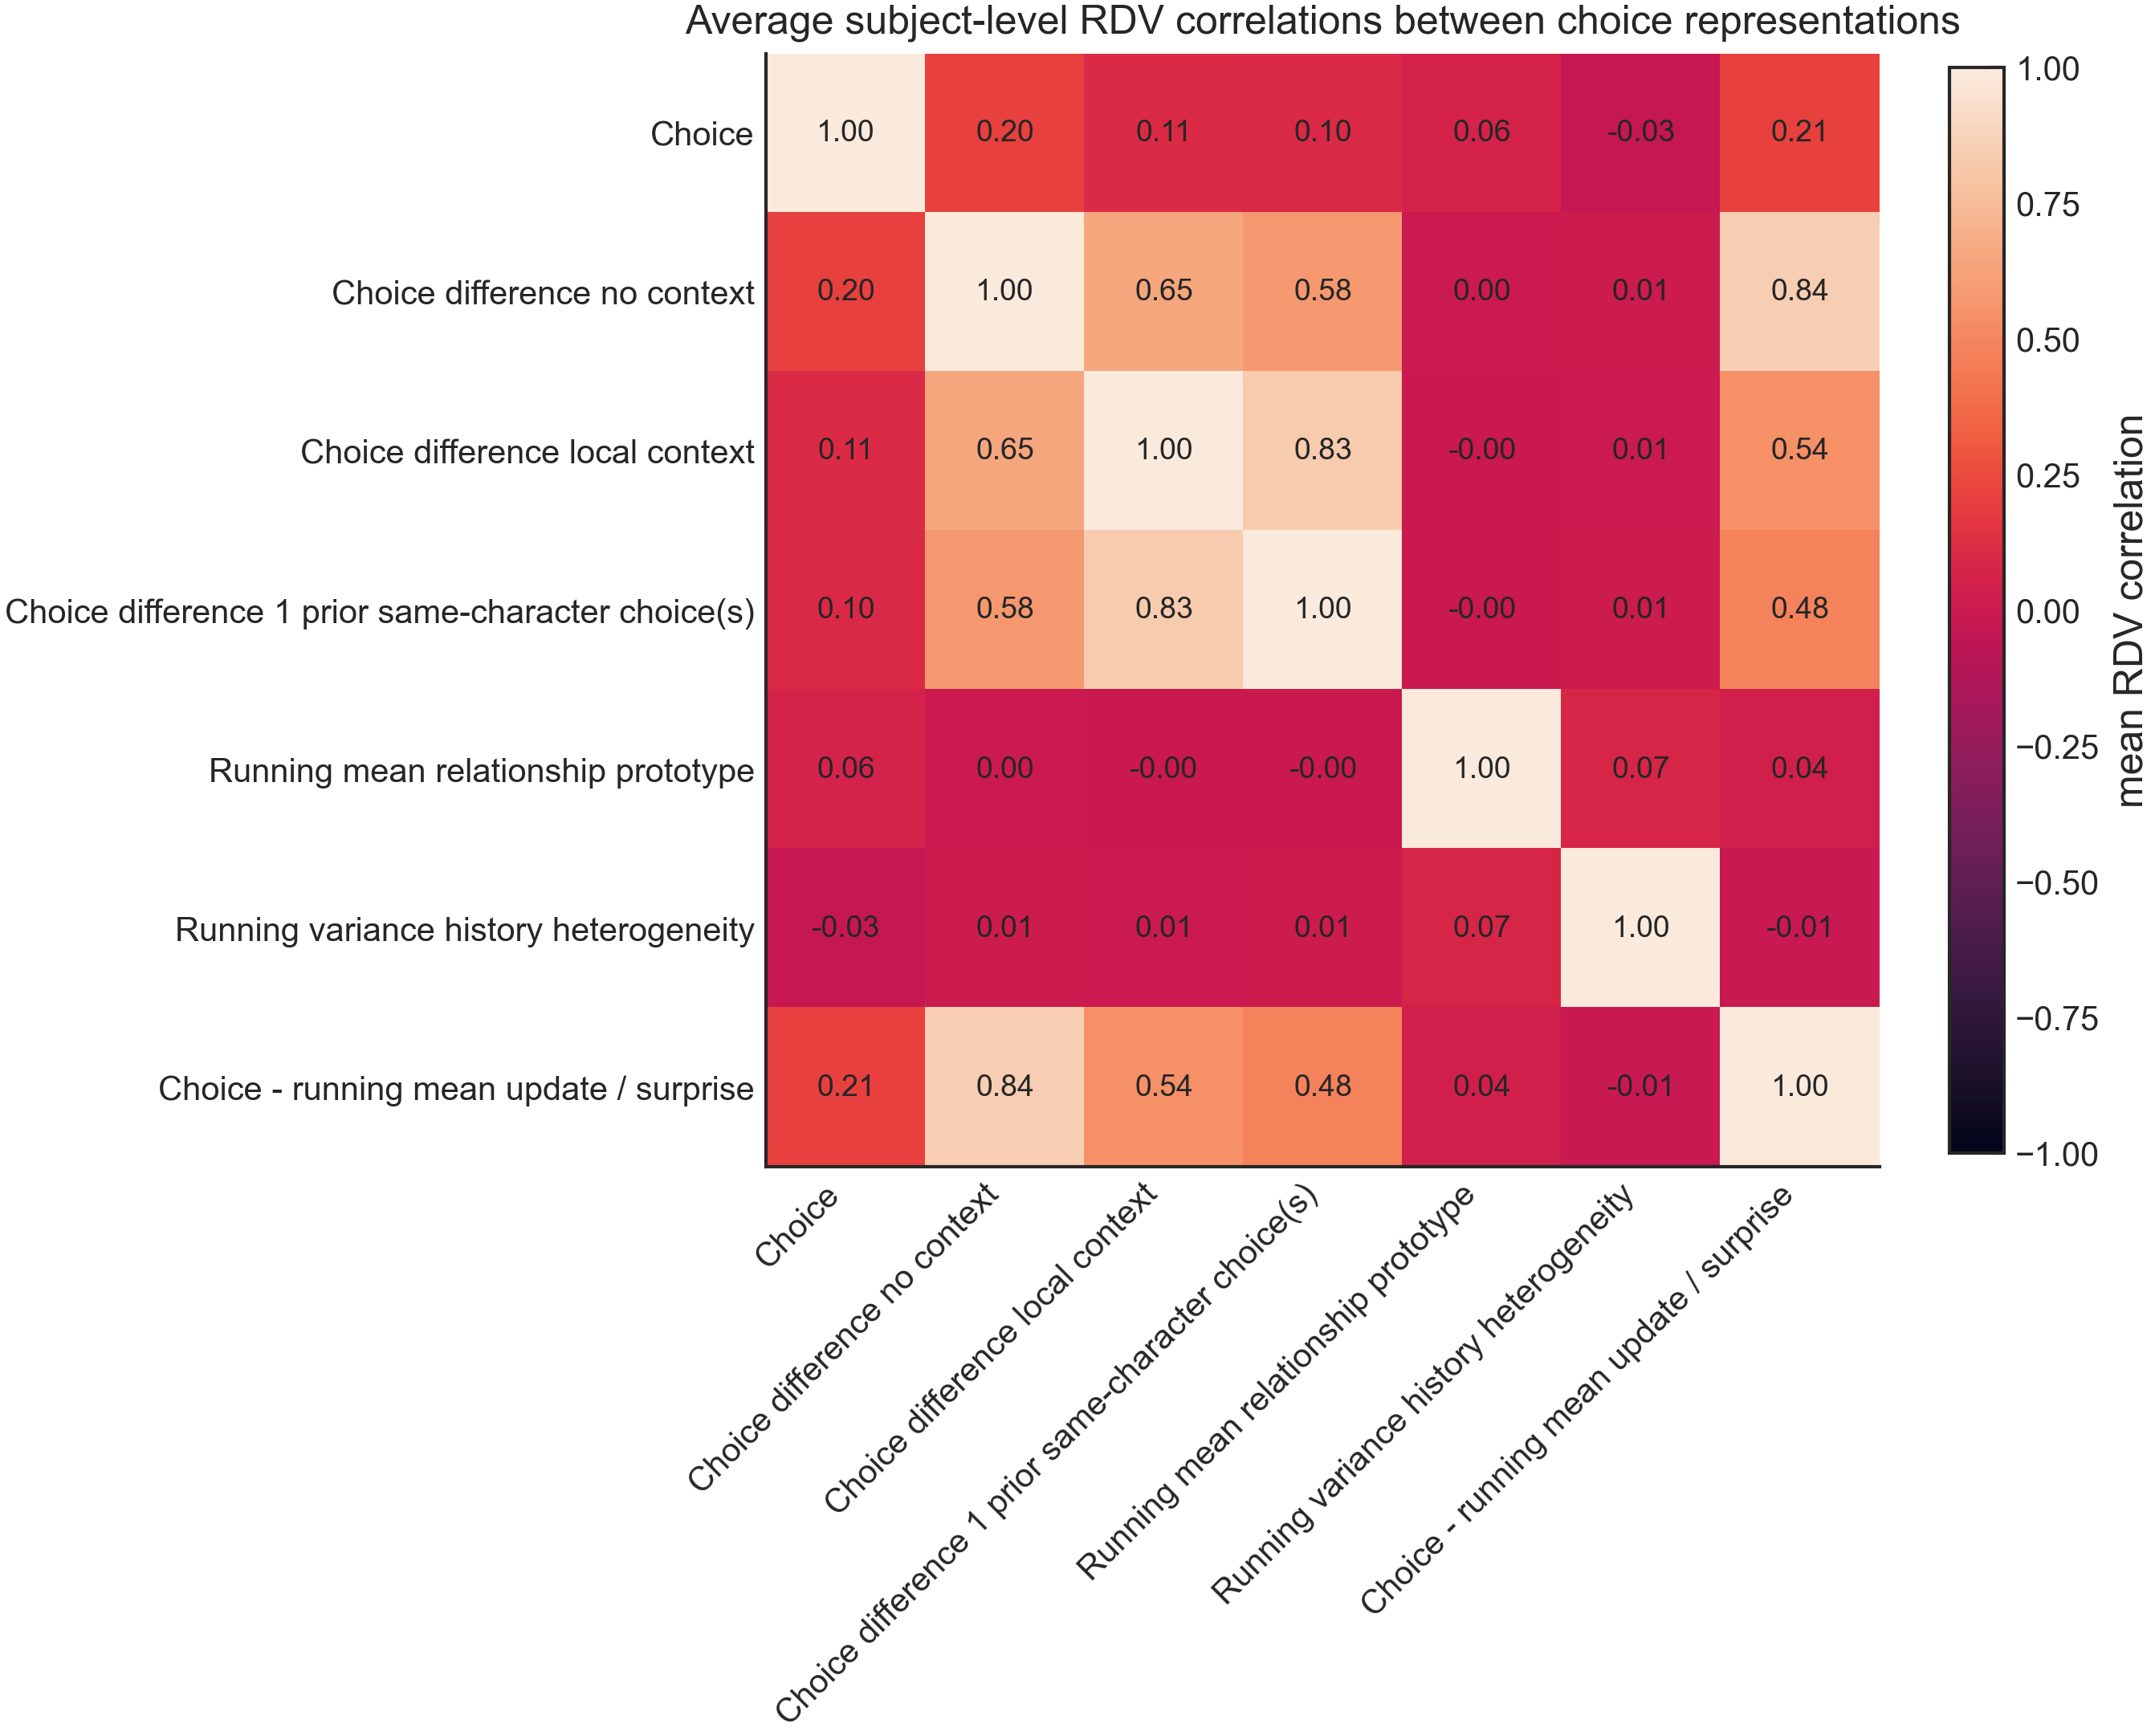

In [5]:
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# RDV correlation helpers
# ============================================================

def _l2_normalize(X, axis=1, eps=1e-8):
    X = np.asarray(X, dtype=float)
    return X / (np.linalg.norm(X, axis=axis, keepdims=True) + eps)

def _safe_corr(x, y, *, method="pearson", eps=1e-12):
    """
    Correlates two vectors, ignoring NaNs.

    method:
        "pearson"
        "spearman"
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) < 3:
        return np.nan

    if method == "spearman":
        x = pd.Series(x).rank(method="average").to_numpy()
        y = pd.Series(y).rank(method="average").to_numpy()
    elif method != "pearson":
        raise ValueError("method must be 'pearson' or 'spearman'.")

    x = x - x.mean()
    y = y - y.mean()

    x_norm = np.sqrt(np.sum(x ** 2))
    y_norm = np.sqrt(np.sum(y ** 2))

    if x_norm < eps or y_norm < eps:
        return np.nan

    return float(np.sum(x * y) / (x_norm * y_norm))

def _fisher_mean(rs, eps=1e-7):
    """
    Fisher-z average of correlations.
    """
    rs = np.asarray(rs, dtype=float)
    rs = rs[np.isfinite(rs)]

    if len(rs) == 0:
        return np.nan

    rs = np.clip(rs, -1 + eps, 1 - eps)
    return float(np.tanh(np.mean(np.arctanh(rs))))

def _compute_prior_n(df):
    """
    Computes how many previous trials exist within each subject-character history.

    Needed so running_mean and surprise exclude the first trial, and
    running_variance excludes trials with insufficient prior history.
    """
    prior_n = np.zeros(len(df), dtype=int)

    for _, g in df.groupby(["sub_id", "character_role_num"], sort=False):
        idx = g.sort_values("_trial_order").index.to_numpy()
        prior_n[idx] = np.arange(len(idx))

    return prior_n

def _default_distance_metric_for_rep(rep_name, values):
    """
    Chooses the appropriate within-subject representational distance metric.

    Vector representations:
        cosine distance

    Scalar representations:
        absolute difference
    """
    values = np.asarray(values)

    if values.ndim == 1:
        return "absolute"

    if values.ndim == 2:
        return "cosine"

    raise ValueError(f"Unsupported values shape for {rep_name}: {values.shape}")

def _valid_trial_mask_for_rep(rep_name, values, prior_n):
    """
    Valid trial mask for each representation.

    Prompt-based representations are valid on all finite rows.

    running_mean:
        requires at least 1 prior same-character trial

    surprise:
        requires at least 1 prior same-character trial

    running_variance:
        requires finite scalar value, which usually means >= 2 prior trials
    """
    values = np.asarray(values)

    if values.ndim == 1:
        valid = np.isfinite(values)
    else:
        valid = np.all(np.isfinite(values), axis=1)

    if rep_name in ["running_mean", "surprise", "choice_minus_running_mean"]:
        valid = valid & (prior_n >= 1)

    if rep_name == "running_variance":
        valid = valid & np.isfinite(values) & (prior_n >= 2)

    return valid

def _distance_vector_for_subject(
    values,
    *,
    valid_items=None,
    metric=None,
    item_group=None,
    same_group_only=False,
):
    """
    Computes one representational distance vector for one subject.

    values:
        vector representation: n_items x n_features
        scalar representation: n_items

    valid_items:
        boolean vector of length n_items

    metric:
        "cosine"   -> 1 - cosine similarity
        "absolute" -> absolute scalar difference
        "euclidean" -> Euclidean distance

    item_group:
        optional group labels for items, e.g. character labels

    same_group_only:
        if True, only include distances between items from the same group.
        Useful for asking whether representations agree within character histories.
    """
    values = np.asarray(values, dtype=float)

    if values.ndim == 1:
        n_items = len(values)
    elif values.ndim == 2:
        n_items = values.shape[0]
    else:
        raise ValueError("values must be 1D or 2D.")

    if valid_items is None:
        if values.ndim == 1:
            valid_items = np.isfinite(values)
        else:
            valid_items = np.all(np.isfinite(values), axis=1)
    else:
        valid_items = np.asarray(valid_items, dtype=bool)

    if metric is None:
        metric = "absolute" if values.ndim == 1 else "cosine"

    if metric == "absolute":
        if values.ndim != 1:
            raise ValueError("absolute distance expects 1D scalar values.")
        D = np.abs(values[:, None] - values[None, :])

    elif metric == "cosine":
        if values.ndim != 2:
            raise ValueError("cosine distance expects 2D vector values.")
        X = np.nan_to_num(values, nan=0.0)
        X = _l2_normalize(X)
        D = 1.0 - cosine_similarity(X)
        D = np.clip(D, 0.0, 2.0)

    elif metric == "euclidean":
        if values.ndim != 2:
            raise ValueError("euclidean distance expects 2D vector values.")
        X = np.nan_to_num(values, nan=0.0)
        D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=-1))

    else:
        raise ValueError("metric must be 'cosine', 'absolute', or 'euclidean'.")

    pair_valid = valid_items[:, None] & valid_items[None, :]

    if same_group_only:
        if item_group is None:
            raise ValueError("item_group must be supplied when same_group_only=True.")
        item_group = np.asarray(item_group)
        pair_valid = pair_valid & (item_group[:, None] == item_group[None, :])

    iu = np.triu_indices(n_items, k=1)

    rdv = D[iu].astype(float)
    rdv_valid = pair_valid[iu]

    rdv[~rdv_valid] = np.nan

    return rdv

# ============================================================
# Build subject-level RDVs for each representation
# ============================================================

def compute_subject_rdvs_for_choice_reps(
    rep_out,
    *,
    rep_names=None,
    same_character_only=False,
    distance_metric_overrides=None,
):
    """
    Computes one representational distance vector per subject per representation.

    For each subject:
        each representation is converted into a trial-by-trial RDV.

    Default distance metrics:
        vector-valued reps:
            cosine distance

        scalar-valued reps, especially running_variance:
            absolute difference

    Parameters
    ----------
    rep_out : dict
        Output from run_choice_representation_analysis(...).

    rep_names : list or None
        Representations to include. Defaults to rep_out["rep_names"].

    same_character_only : bool
        False:
            RDV includes all trial pairs within subject.

        True:
            RDV includes only trial pairs from the same character.
            This removes between-character trial pairs and focuses on
            within-relationship representational geometry.

    distance_metric_overrides : dict or None
        Optional mapping, e.g.
            {"running_variance": "absolute", "choice": "cosine"}

    Returns
    -------
    rdvs : dict
        rdvs[rep_name][sub_id] = RDV array

    rdv_info : DataFrame
        Summary of metric and RDV lengths.
    """
    if rep_names is None:
        rep_names = rep_out["rep_names"]

    if distance_metric_overrides is None:
        distance_metric_overrides = {}

    df = rep_out["df"].reset_index(drop=True)
    sub_ids = rep_out["sub_ids"]
    prior_n = _compute_prior_n(df)

    rdvs = {}
    rows = []

    for rep_name in rep_names:
        if rep_name not in rep_out["trial_vectors"]:
            raise ValueError(
                f"{rep_name} not found in rep_out['trial_vectors']. "
                "Re-run the main representation code including this representation."
            )

        values = np.asarray(rep_out["trial_vectors"][rep_name], dtype=float)

        metric = distance_metric_overrides.get(
            rep_name,
            _default_distance_metric_for_rep(rep_name, values),
        )

        valid_all = _valid_trial_mask_for_rep(rep_name, values, prior_n)

        rdvs[rep_name] = {}

        for sub_id in sub_ids:
            sub_mask = df["sub_id"].values == sub_id
            sub_idx = np.where(sub_mask)[0]

            sub_df = df.iloc[sub_idx].sort_values("_trial_order")
            ordered_idx = sub_df.index.to_numpy()

            sub_values = values[ordered_idx]
            sub_valid = valid_all[ordered_idx]
            sub_groups = sub_df["character_role_num"].to_numpy()

            rdv = _distance_vector_for_subject(
                sub_values,
                valid_items=sub_valid,
                metric=metric,
                item_group=sub_groups,
                same_group_only=same_character_only,
            )

            rdvs[rep_name][sub_id] = rdv

        example_lengths = [
            len(rdvs[rep_name][sub_id])
            for sub_id in sub_ids
        ]

        finite_counts = [
            np.isfinite(rdvs[rep_name][sub_id]).sum()
            for sub_id in sub_ids
        ]

        rows.append({
            "representation": rep_name,
            "label": rep_out["metadata"][rep_name]["label"].replace("\n", " "),
            "distance_metric": metric,
            "same_character_only": same_character_only,
            "rdv_length_min": int(np.min(example_lengths)),
            "rdv_length_max": int(np.max(example_lengths)),
            "finite_pairs_mean": float(np.mean(finite_counts)),
            "finite_pairs_min": int(np.min(finite_counts)),
            "finite_pairs_max": int(np.max(finite_counts)),
        })

    rdv_info = pd.DataFrame(rows)

    return rdvs, rdv_info

# ============================================================
# Correlate RDVs across representations, then average over subjects
# ============================================================

def compute_subject_rdv_rep_correlations(
    rep_out,
    *,
    rep_names=None,
    method="pearson",
    same_character_only=False,
    distance_metric_overrides=None,
):
    """
    For each subject:
        correlate RDVs between every pair of representations.

    Then:
        Fisher-z average those correlations across subjects.

    Returns
    -------
    mean_corr_df : DataFrame
        Fisher-averaged subject-level RDV correlations.

    n_valid_df : DataFrame
        Number of subjects with valid RDV correlations per cell.

    long_df : DataFrame
        Long-format summary.

    subject_corrs : dict
        subject_corrs[(rep_i, rep_j)] = array of subject-level correlations

    rdvs : dict
        rdvs[rep_name][sub_id] = RDV array

    rdv_info : DataFrame
        Summary of RDV construction.
    """
    if rep_names is None:
        rep_names = rep_out["rep_names"]

    rdvs, rdv_info = compute_subject_rdvs_for_choice_reps(
        rep_out,
        rep_names=rep_names,
        same_character_only=same_character_only,
        distance_metric_overrides=distance_metric_overrides,
    )

    sub_ids = rep_out["sub_ids"]
    n_reps = len(rep_names)

    mean_corr = np.eye(n_reps)
    n_valid = np.full((n_reps, n_reps), len(sub_ids), dtype=int)

    rows = []
    subject_corrs = {}

    for i, rep_i in enumerate(rep_names):
        for j, rep_j in enumerate(rep_names):
            if j < i:
                continue

            if i == j:
                rs = np.ones(len(sub_ids))
                r_mean = 1.0

            else:
                rs = np.array([
                    _safe_corr(
                        rdvs[rep_i][sub_id],
                        rdvs[rep_j][sub_id],
                        method=method,
                    )
                    for sub_id in sub_ids
                ])

                r_mean = _fisher_mean(rs)

            mean_corr[i, j] = r_mean
            mean_corr[j, i] = r_mean

            n_good = int(np.isfinite(rs).sum())
            n_valid[i, j] = n_good
            n_valid[j, i] = n_good

            subject_corrs[(rep_i, rep_j)] = rs
            subject_corrs[(rep_j, rep_i)] = rs

            if i != j:
                rows.append({
                    "rep_1": rep_i,
                    "rep_2": rep_j,
                    "mean_r_fisher": r_mean,
                    "median_subject_r": float(np.nanmedian(rs)),
                    "sd_subject_r": float(np.nanstd(rs)),
                    "n_subjects": n_good,
                    "method": method,
                    "same_character_only": same_character_only,
                    "distance_1": rdv_info.loc[
                        rdv_info["representation"] == rep_i,
                        "distance_metric"
                    ].iloc[0],
                    "distance_2": rdv_info.loc[
                        rdv_info["representation"] == rep_j,
                        "distance_metric"
                    ].iloc[0],
                })

    mean_corr_df = pd.DataFrame(mean_corr, index=rep_names, columns=rep_names)
    n_valid_df = pd.DataFrame(n_valid, index=rep_names, columns=rep_names)
    long_df = pd.DataFrame(rows)

    return mean_corr_df, n_valid_df, long_df, subject_corrs, rdvs, rdv_info

# ============================================================
# Plotting
# ============================================================

def plot_subject_rdv_rep_correlation_heatmap(
    corr_df,
    *,
    labels=None,
    title="Average subject-level RDV correlations between representations",
    figsize=None,
    vmin=-1,
    vmax=1,
):
    """
    Plots a heatmap of Fisher-averaged subject-level RDV correlations.
    """
    names = corr_df.index.tolist()

    if labels is None:
        labels = names

    if figsize is None:
        figsize = (0.9 * len(names) + 3.0, 0.8 * len(names) + 2.5)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(corr_df.values, vmin=vmin, vmax=vmax, aspect="equal")

    ax.set_xticks(np.arange(len(names)))
    ax.set_yticks(np.arange(len(names)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_title(title)

    for i in range(len(names)):
        for j in range(len(names)):
            val = corr_df.iloc[i, j]
            txt = "" if not np.isfinite(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, shrink=0.8, label="mean RDV correlation")
    plt.tight_layout()
    plt.show()

# ============================================================
# Run: all trial-pair RDVs within subject
# ============================================================

REPRESENTATIONS_TO_CORRELATE = out_choice_reps["rep_names"]

rdv_corr_df, rdv_n_df, rdv_long_df, subject_rdv_corrs, rdvs, rdv_info = (
    compute_subject_rdv_rep_correlations(
        out_choice_reps,
        rep_names=REPRESENTATIONS_TO_CORRELATE,
        method="pearson",
        same_character_only=False,
        distance_metric_overrides=None,
    )
)

labels = [
    out_choice_reps["metadata"][name]["label"].replace("\n", " ")
    for name in REPRESENTATIONS_TO_CORRELATE
]

plot_subject_rdv_rep_correlation_heatmap(
    rdv_corr_df,
    labels=labels,
    title="Average subject-level RDV correlations between choice representations",
    vmin=-1,
    vmax=1,
)

<h1 align=center> Choice contrasts </h1>

Variance explained: [0.06885617 0.05524373 0.05162439 0.04239636 0.04024368]


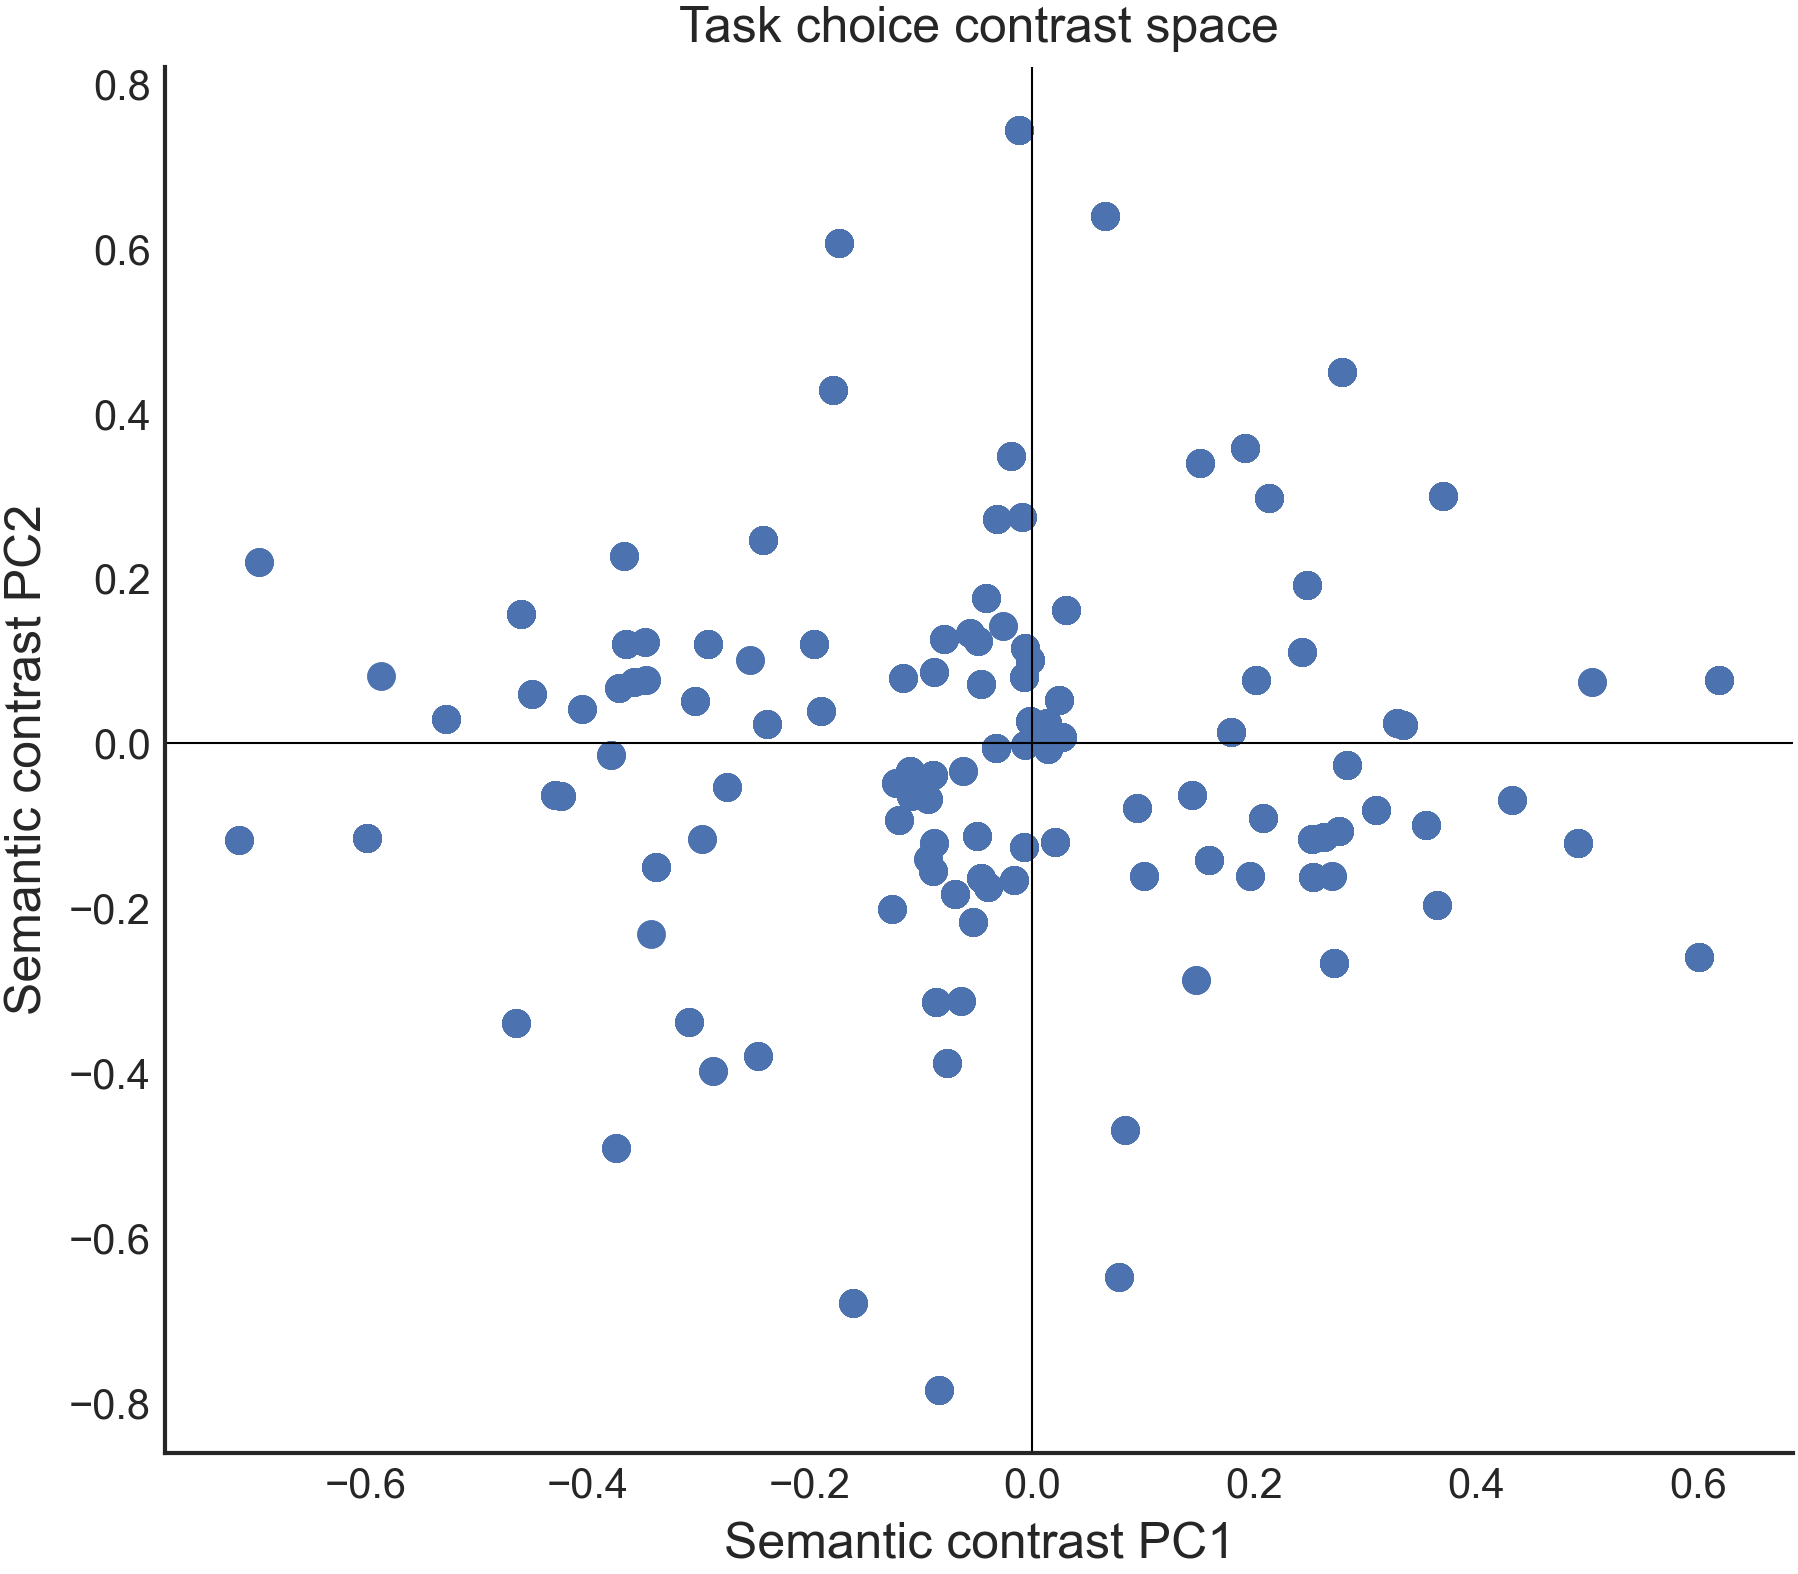

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


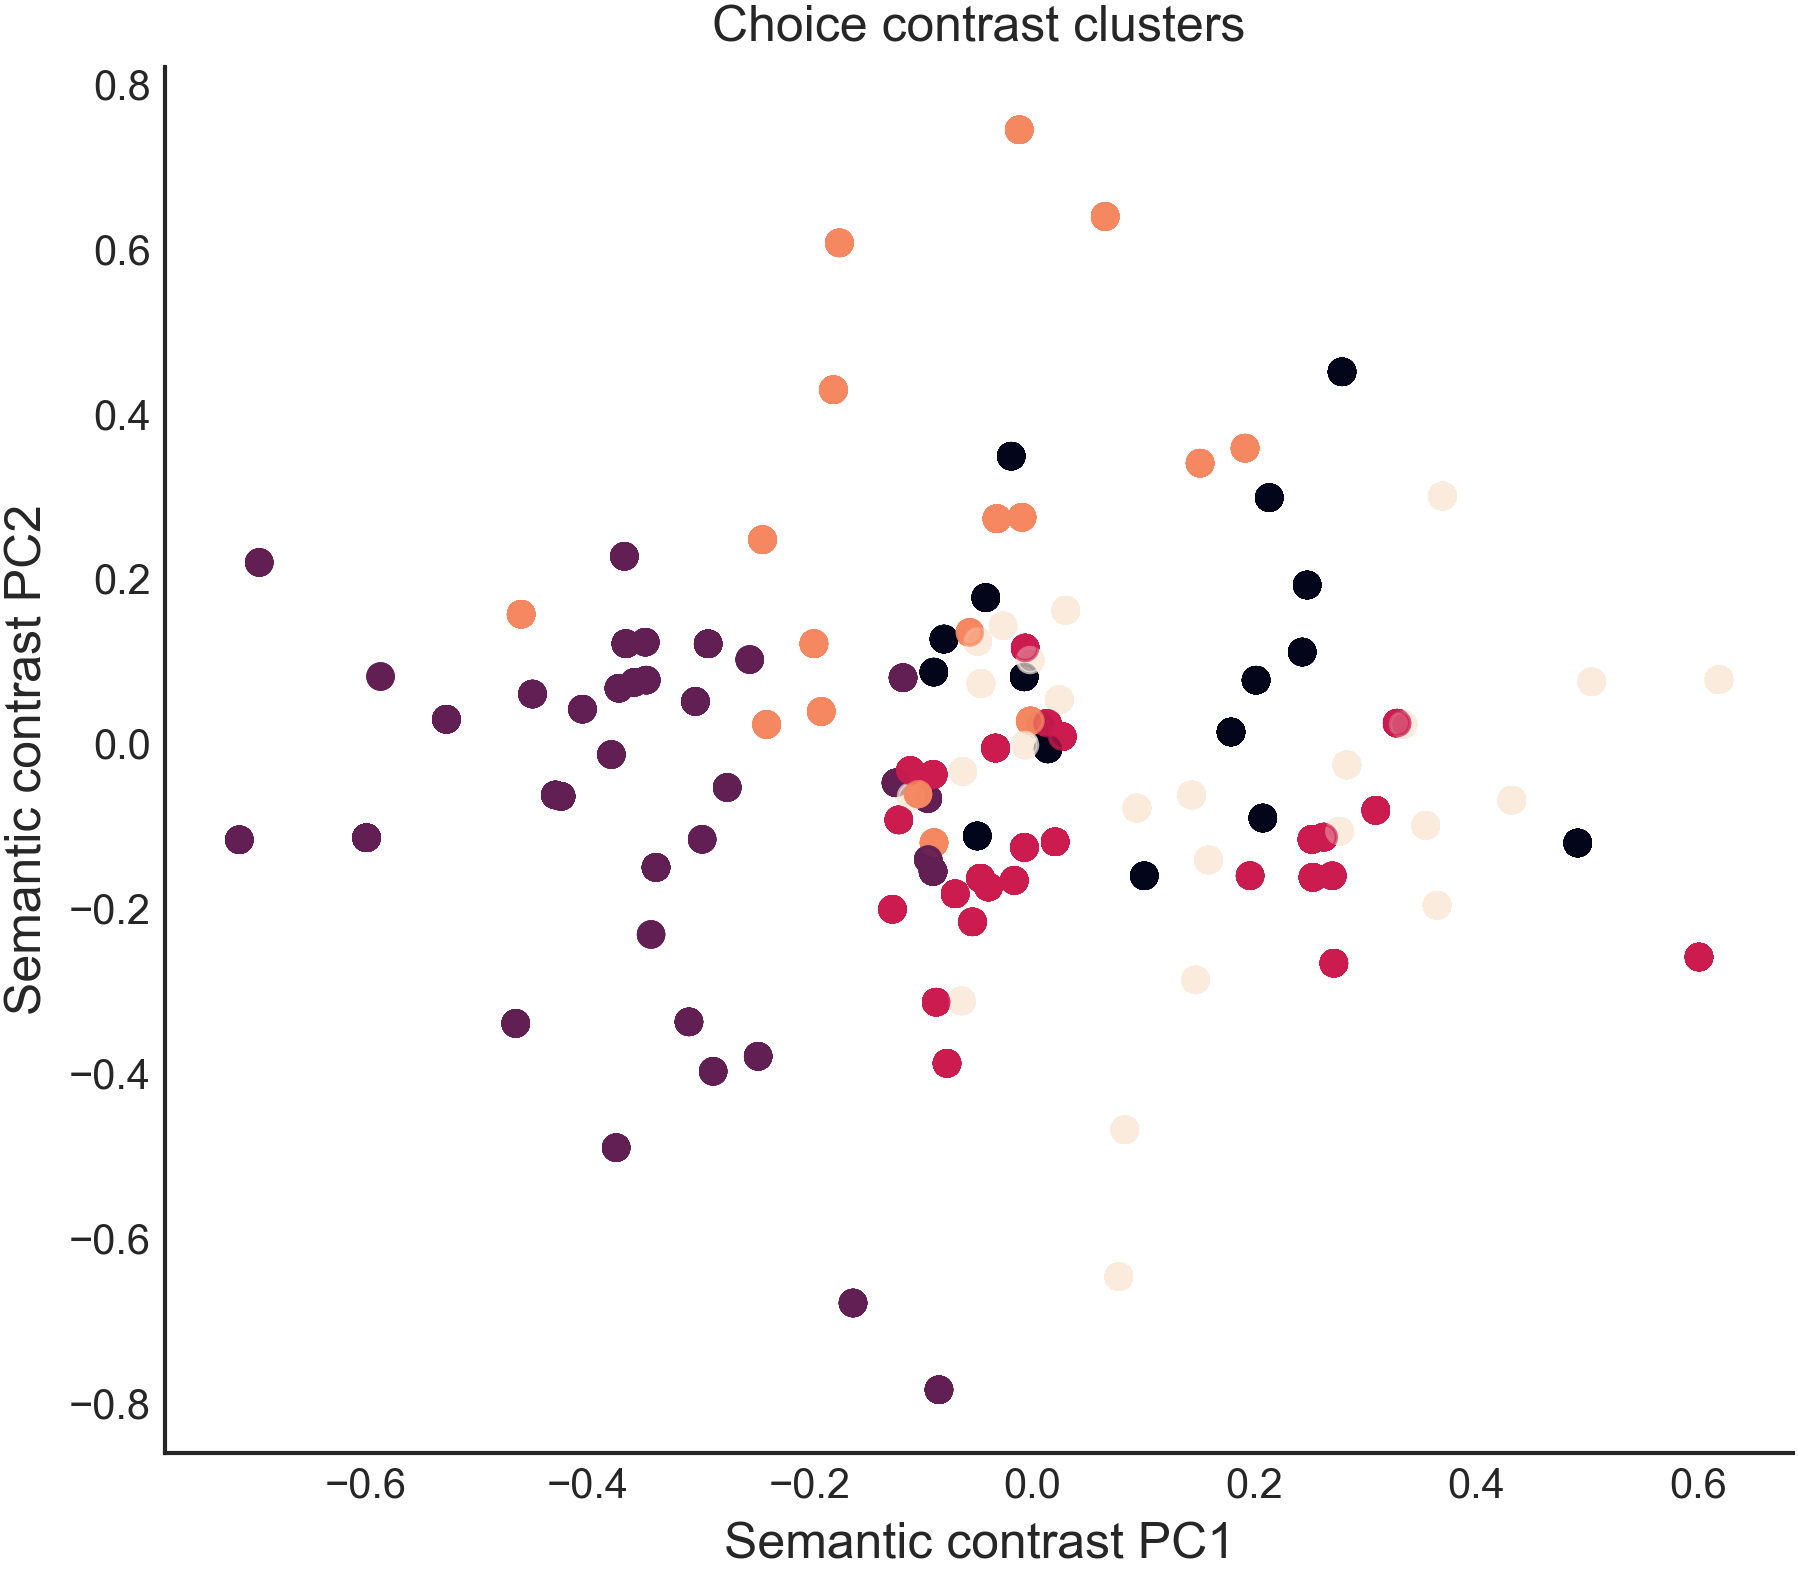

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# use the basic choice contrast vectors
X = np.asarray(
    out_choice_reps["trial_vectors"]["choice_diff"],
    float
)

# normalize
X = X / np.linalg.norm(X, axis=1, keepdims=True)


# PCA
pca = PCA(n_components=10)
Z = pca.fit_transform(X)

print("Variance explained:", pca.explained_variance_ratio_[:5])


# plot first two PCs
plt.figure(figsize=(7,6))
plt.scatter(
    Z[:,0],
    Z[:,1],
    alpha=.5
)

plt.xlabel("Semantic contrast PC1")
plt.ylabel("Semantic contrast PC2")
plt.title("Task choice contrast space")
plt.axhline(0,color="black",lw=.5)
plt.axvline(0,color="black",lw=.5)
plt.show()


# clustering
kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(Z[:,:10])


plt.figure(figsize=(7,6))
plt.scatter(
    Z[:,0],
    Z[:,1],
    c=clusters,
    alpha=.6
)

plt.xlabel("Semantic contrast PC1")
plt.ylabel("Semantic contrast PC2")
plt.title("Choice contrast clusters")
plt.show()

## Decoding affiliation v. power from choice cntrasts

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, roc_auc_score


# -------------------------------
# Data
# -------------------------------

X = np.asarray(
    out_choice_reps["trial_vectors"]["choice_diff"],
    float
)

# Normalize contrast vectors without dividing zero-length rows by zero.
norms = np.linalg.norm(X, axis=1)
valid_vectors = np.isfinite(X).all(axis=1) & (norms > 1e-12)
X = X / np.where(norms > 1e-12, norms, 1.0)[:, None]


df = out_choice_reps["df"].copy().reset_index(drop=True)

if len(df) != len(X):
    raise ValueError(f"Trial table/vector mismatch: {len(df)} rows versus {len(X)} vectors.")
if "decision_num" not in df.columns:
    raise KeyError("out_choice_reps['df'] must contain decision_num for task metadata.")

# Attach the canonical affiliation/power label from the task design.
task_dimensions = decision_trials[["decision_num", "dimension"]].copy()
if task_dimensions["decision_num"].duplicated().any():
    raise ValueError("decision_trials has duplicate decision_num values.")
dimension_by_trial = task_dimensions.set_index("decision_num")["dimension"]
df["dimension"] = df["decision_num"].map(dimension_by_trial)
if df["dimension"].isna().any():
    missing_trials = sorted(df.loc[df["dimension"].isna(), "decision_num"].unique())
    raise ValueError(f"Missing dimension labels for decisions {missing_trials}.")


# affiliation = 1, power = 0
y = (
    df["dimension"]
    .map({"affil": 1, "power": 0})
    .to_numpy(dtype=float)
)


valid = valid_vectors & np.isfinite(y)

X = X[valid]
y = y[valid]
df = df.loc[valid].reset_index(drop=True)


# -------------------------------
# Cross validated classifier
# -------------------------------

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000
    )
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)


# predicted probability of affiliation
p_affil = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:,1]


pred = (p_affil > .5).astype(int)


print(
    "Accuracy:",
    accuracy_score(y,pred)
)

print(
    "AUC:",
    roc_auc_score(y,p_affil)
)


# classifier output
df["p_affil"] = p_affil


# -------------------------------
# Subject summaries
# -------------------------------

sub_scores = (
    df.groupby("sub_id")
    .agg(
        mean_affiliation_axis=("p_affil","mean"),
        choice_consistency=("p_affil",
                            lambda x: np.mean(
                                np.abs(x-.5)*2
                            ))
    )
    .reset_index()
)


# add diagnosis / trauma
sub_scores = sub_scores.merge(
    data[["sub_id","dx","ctq_score"]],
    on="sub_id",
    how="left"
)


sub_scores.head()

Accuracy: 0.6919886487666448
AUC: 0.7524654358643579


,sub_id,mean_affiliation_axis,choice_consistency,dx,ctq_score
0,18001,0.461748,0.395966,0,27
1,18002,0.497519,0.421358,0,35
2,18003,0.459568,0.397364,0,43
3,18004,0.525475,0.402517,1,61
4,18005,0.500898,0.386403,0,27


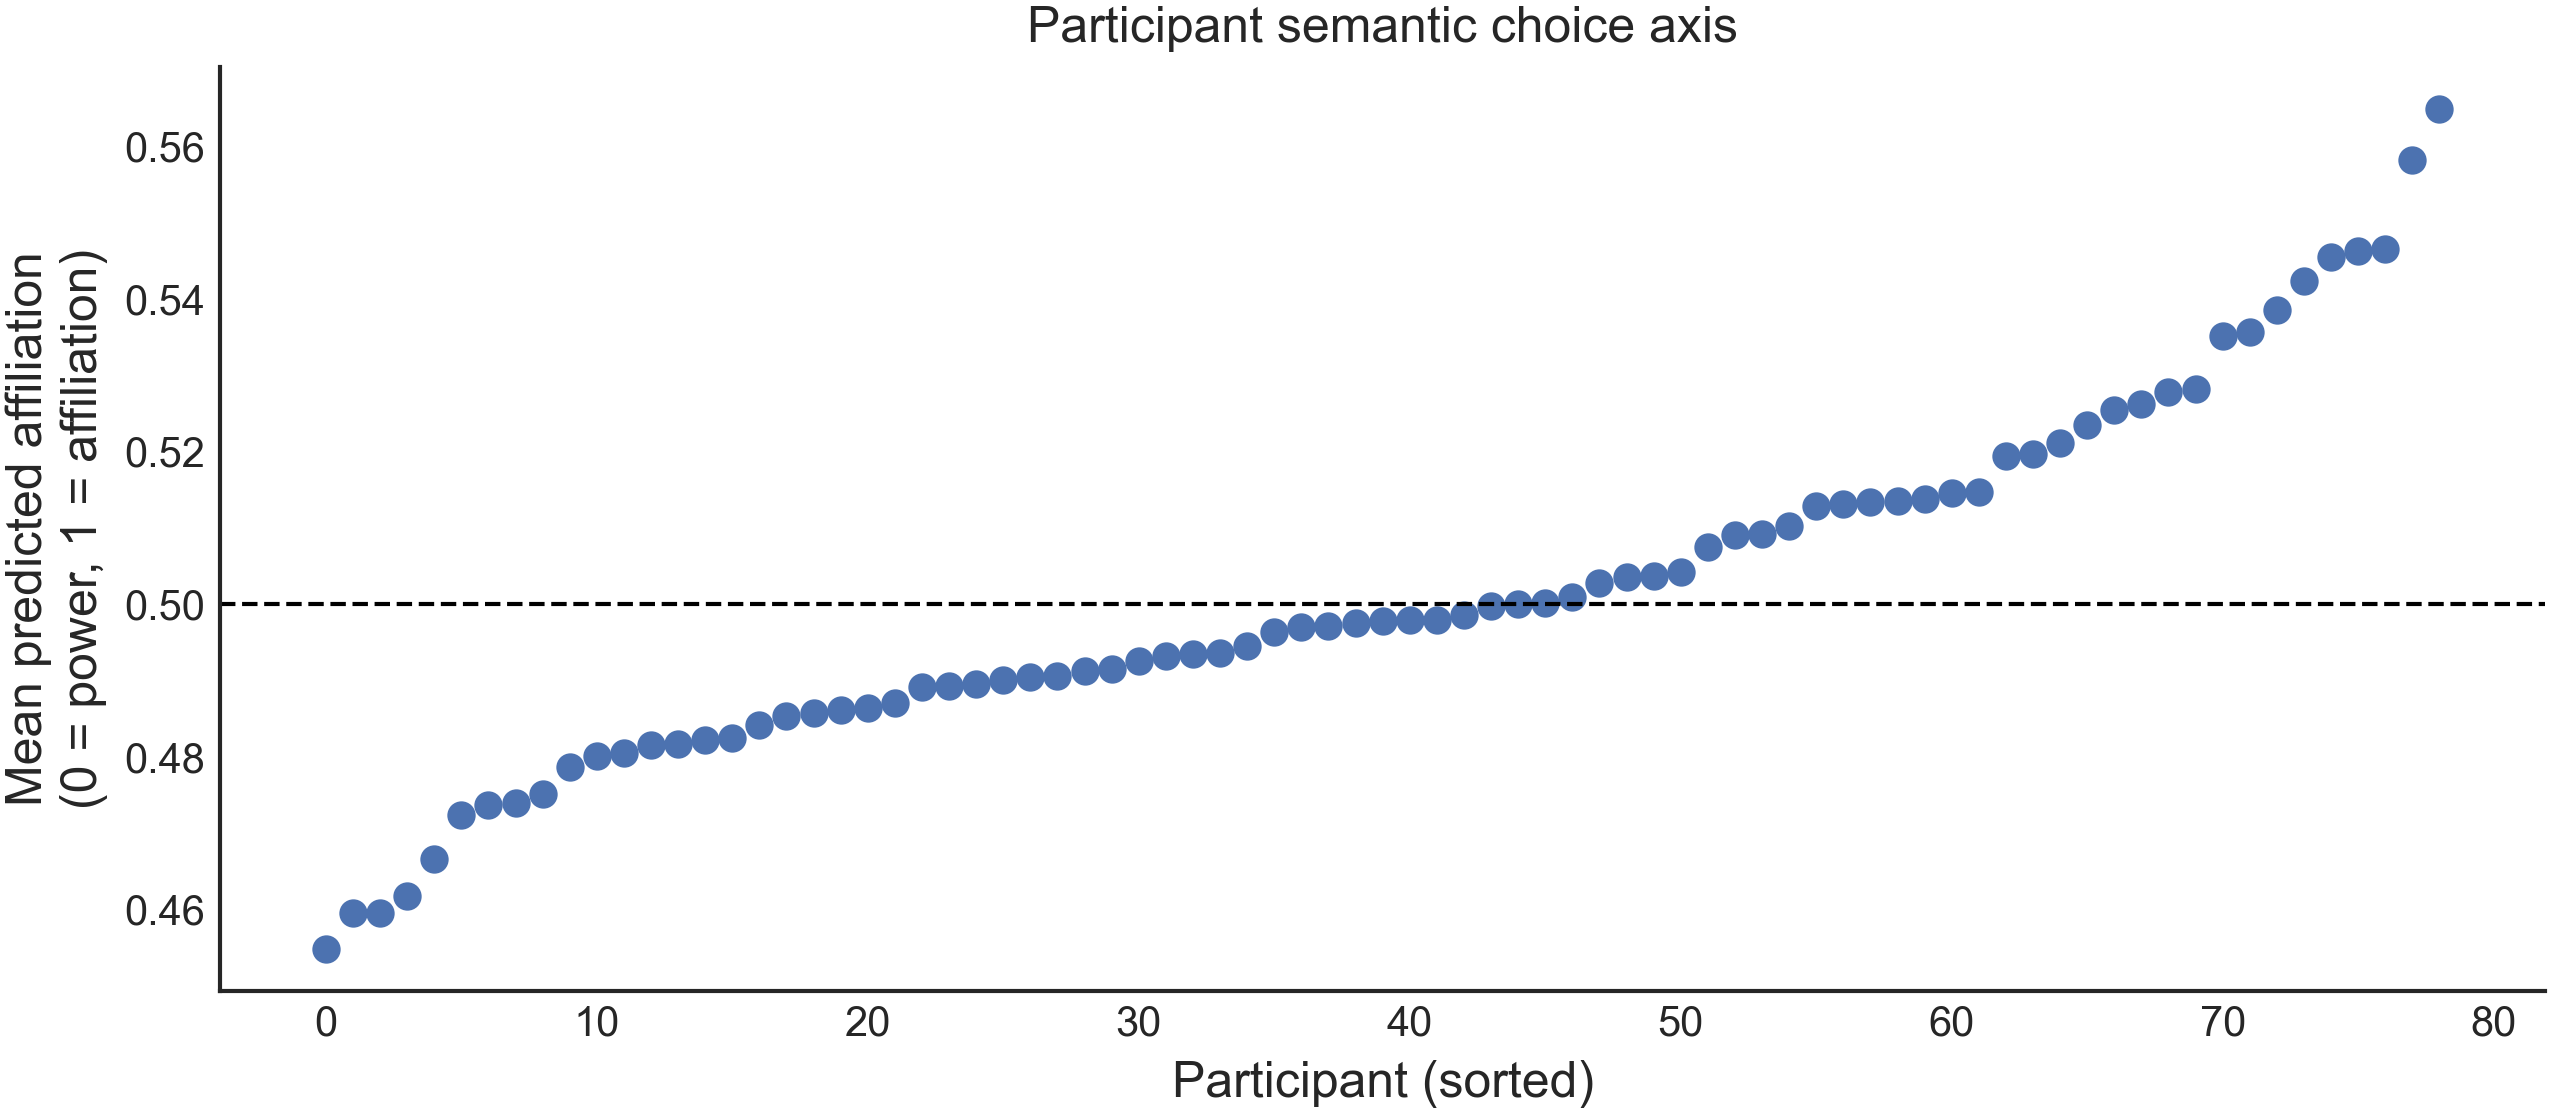

In [18]:
plt.figure(figsize=(10,4))

plot_df = sub_scores.sort_values(
    "mean_affiliation_axis"
)

plt.scatter(
    np.arange(len(plot_df)),
    plot_df["mean_affiliation_axis"],
)

plt.axhline(
    .5,
    color="black",
    linestyle="--"
)

plt.ylabel(
    "Mean predicted affiliation\n(0 = power, 1 = affiliation)"
)

plt.xlabel(
    "Participant (sorted)"
)

plt.title(
    "Participant semantic choice axis"
)

plt.show()

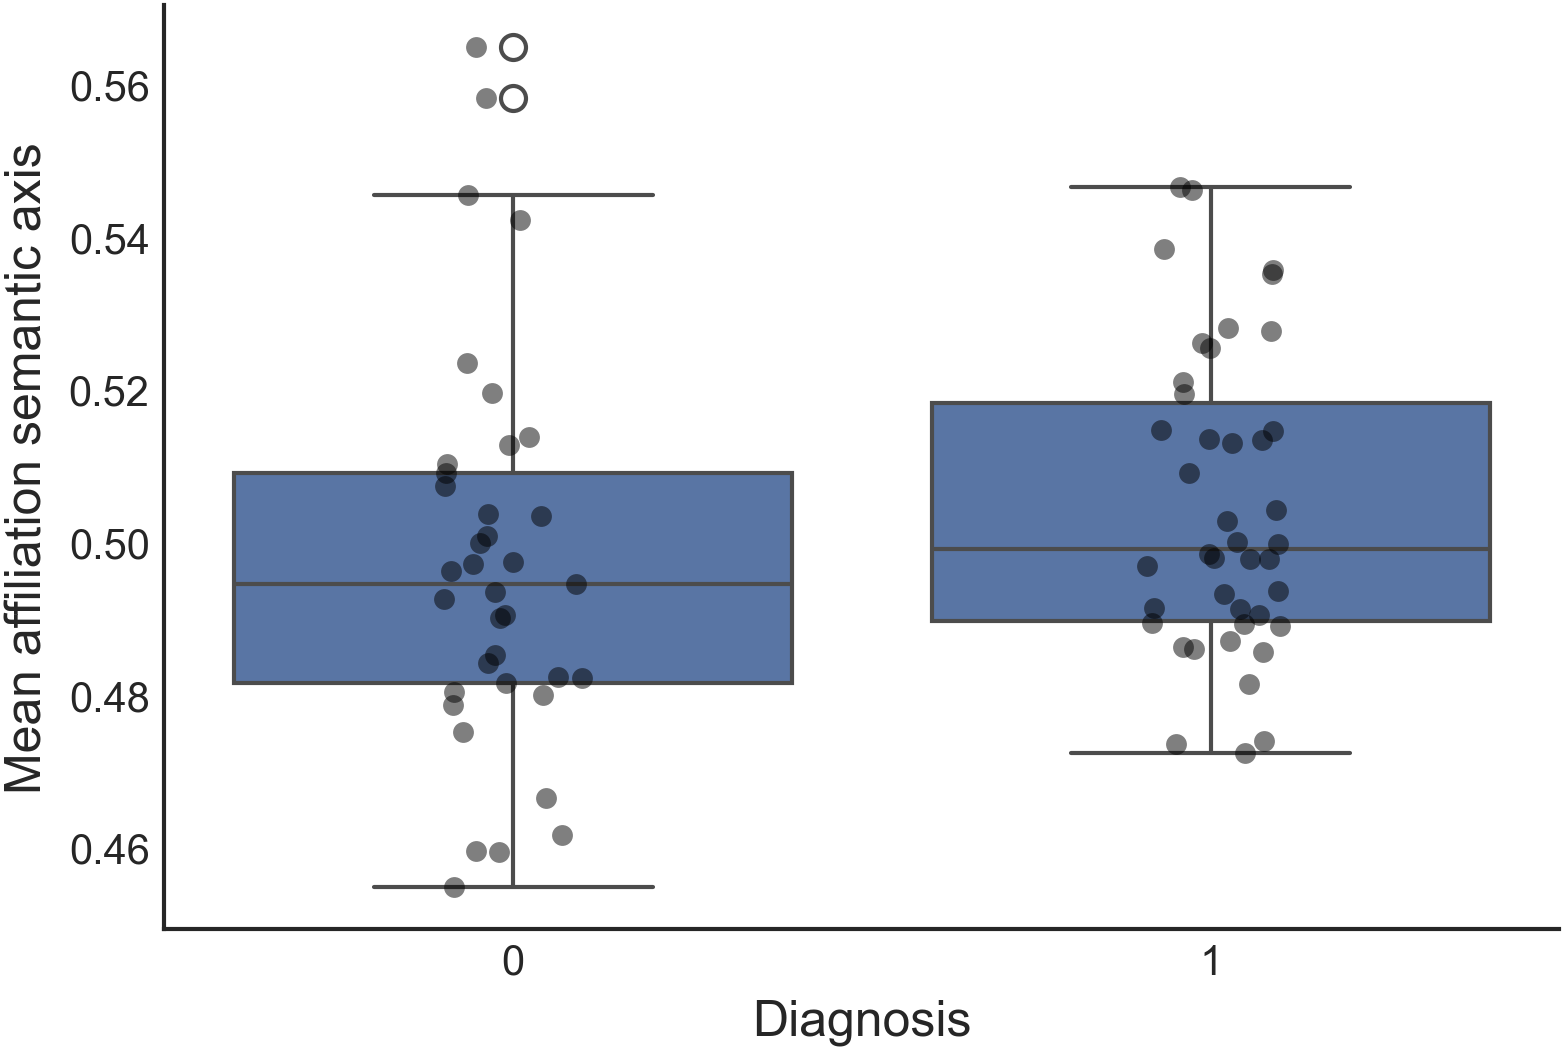

TtestResult(statistic=np.float64(-1.419821110277514), pvalue=np.float64(0.16030330718104746), df=np.float64(66.89628925024665))
CTQ correlation: -0.22509982922095517 0.0460955064100065


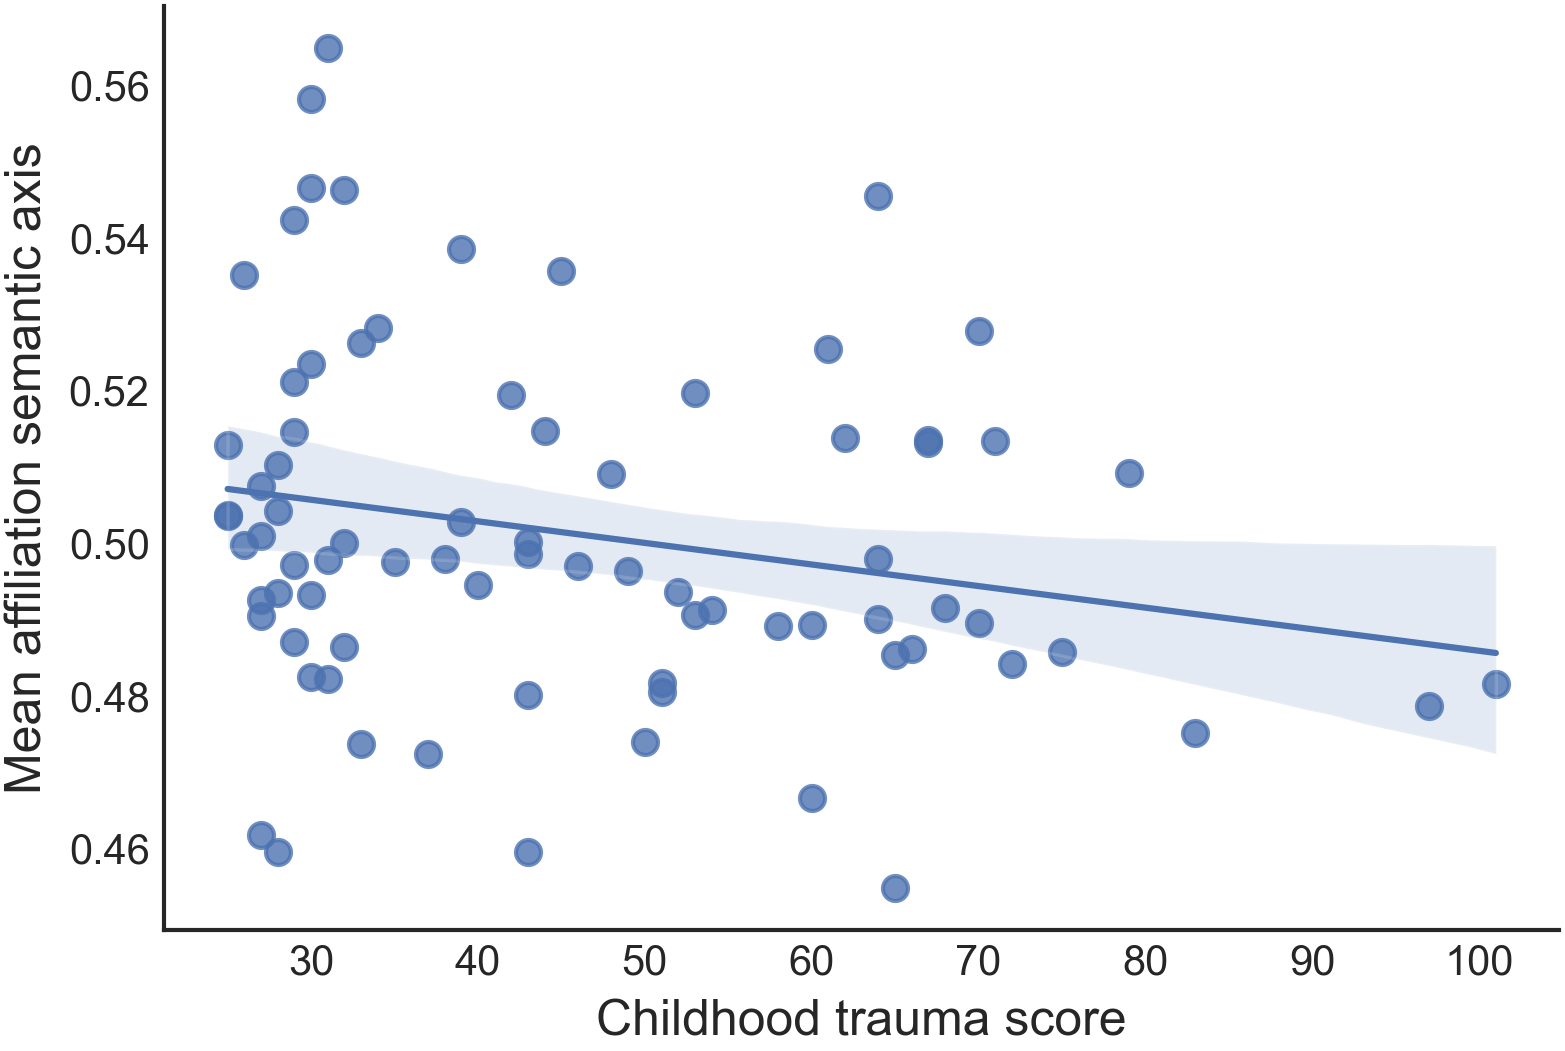

In [20]:
import seaborn as sns
import scipy.stats as st


plt.figure(figsize=(6,4))

sns.boxplot(
    data=sub_scores,
    x="dx",
    y="mean_affiliation_axis"
)

sns.stripplot(
    data=sub_scores,
    x="dx",
    y="mean_affiliation_axis",
    color="black",
    alpha=.5
)

plt.ylabel(
    "Mean affiliation semantic axis"
)

plt.xlabel(
    "Diagnosis"
)

plt.show()


# statistical test

hc = sub_scores.query("dx==0")["mean_affiliation_axis"]
cd = sub_scores.query("dx==1")["mean_affiliation_axis"]


print(
    st.ttest_ind(
        hc,
        cd,
        equal_var=False
    )
)


from scipy.stats import pearsonr


tmp = sub_scores.dropna(
    subset=[
        "ctq_score",
        "mean_affiliation_axis"
    ]
)


r,p = pearsonr(
    tmp["ctq_score"],
    tmp["mean_affiliation_axis"]
)


print(
    "CTQ correlation:",
    r,
    p
)


plt.figure(figsize=(6,4))

sns.regplot(
    data=tmp,
    x="ctq_score",
    y="mean_affiliation_axis"
)

plt.ylabel(
    "Mean affiliation semantic axis"
)

plt.xlabel(
    "Childhood trauma score"
)

plt.show()

### Extract learned direction and project the choices

Classifier direction shape: (768,)


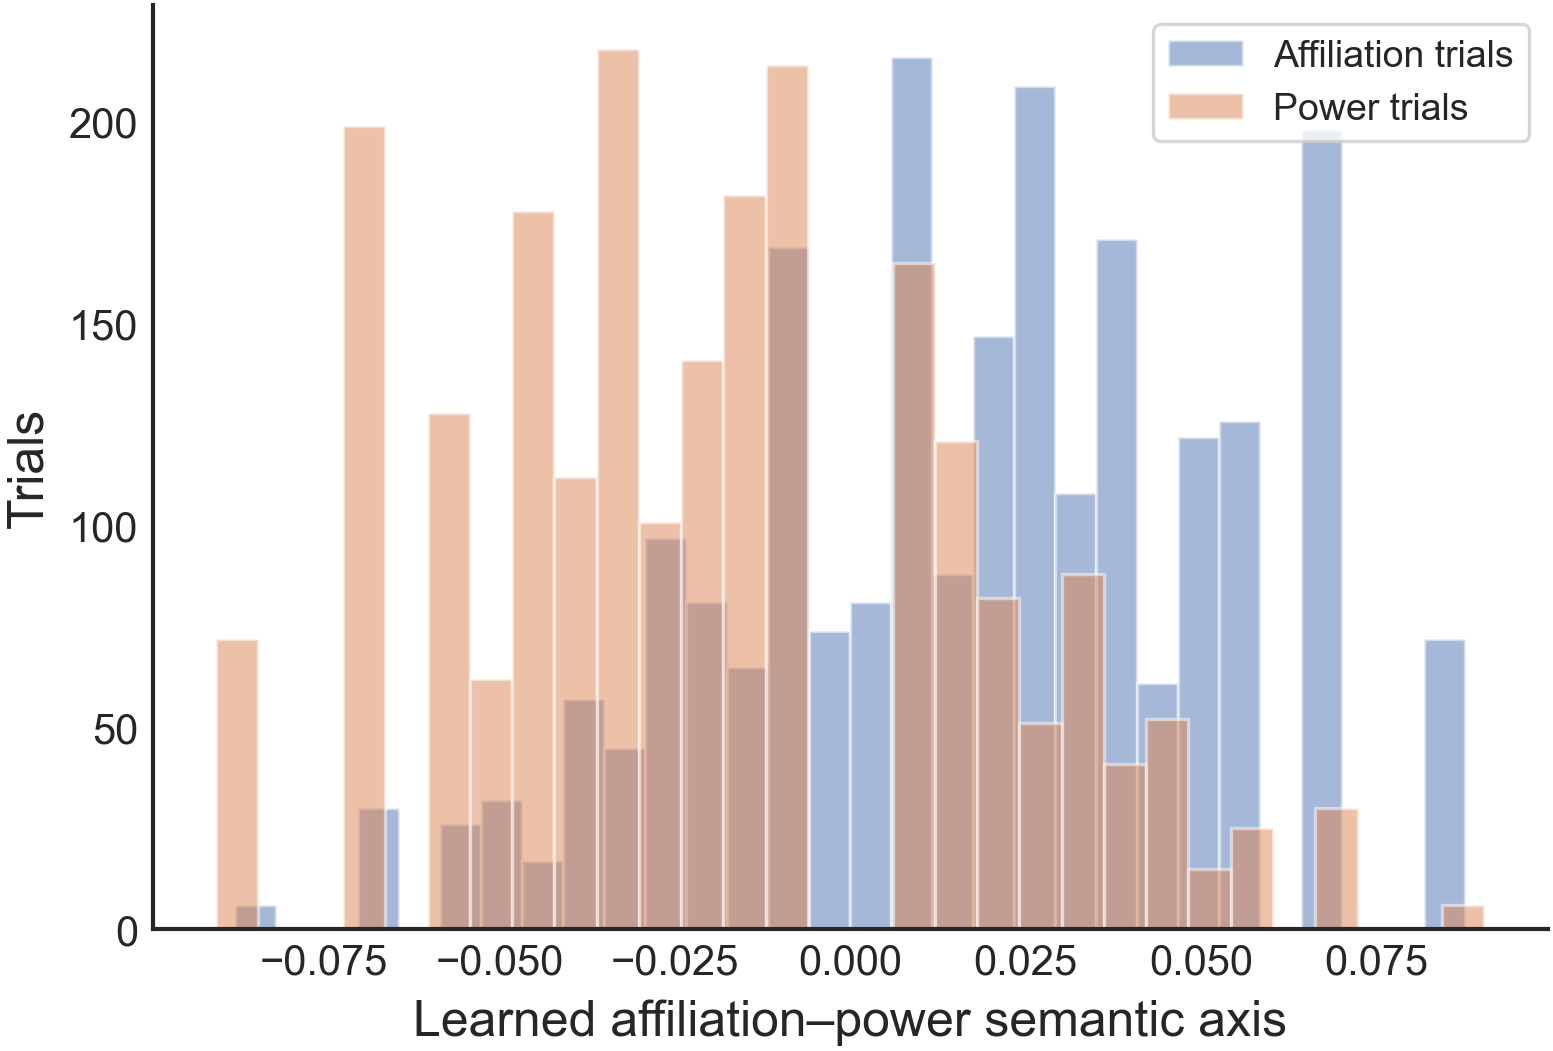

In [ ]:
# fit final model on all data

clf.fit(X,y)

weights = (
    clf[-1]
    .coef_[0]
)

print(
    "Classifier direction shape:",
    weights.shape
)


# project every trial onto the affiliation-power axis

axis_projection = X @ weights

plt.figure(figsize=(6,4))

plt.hist(
    axis_projection[y==1],
    bins=30,
    alpha=.5,
    label="Affiliation trials"
)

plt.hist(
    axis_projection[y==0],
    bins=30,
    alpha=.5,
    label="Power trials"
)

plt.xlabel(
    "Learned affiliation–power semantic axis"
)

plt.ylabel(
    "Trials"
)

plt.legend()

plt.show()

## RSA to decompose task structure
TODO add more in the original df/dictionary so this is easier

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

def vector_rdm(X):
    """
    Cosine distance RDM.
    """
    X = np.asarray(X,float)
    X = X / np.linalg.norm(X,axis=1,keepdims=True)

    return pdist(X, metric="cosine")

def make_binary_rdm(x):
    """
    0 if same, 1 if different
    """
    x = np.asarray(x)
    return pdist(
        x[:,None],
        metric=lambda a,b: float(a[0]!=b[0])
    )

def make_numeric_rdm(x):
    """
    Absolute difference.
    """
    return pdist(
        np.asarray(x)[:,None],
        metric="cityblock"
    )

def semantic_rsa(
    df,
    embeddings,
    task_vars=[
        "dimension",
        "character_role_num",
        "scene_num",
        "character_decision_num",
    ],
):

    # semantic distance
    y = vector_rdm(embeddings)


    # task predictors
    X = []

    names=[]

    for var in task_vars:

        if var not in df.columns:
            continue

        x=df[var].values

        if df[var].dtype=="object":
            rdm=make_binary_rdm(x)

        else:
            rdm=make_numeric_rdm(x)

        X.append(rdm)
        names.append(var)


    X=np.column_stack(X)


    # remove missing
    valid=np.isfinite(y).all() if False else np.isfinite(y)

    valid &= np.isfinite(X).all(axis=1)

    y=y[valid]
    X=X[valid]


    # standardize
    X=StandardScaler().fit_transform(X)
    y=StandardScaler().fit_transform(
        y[:,None]
    ).ravel()


    model=LinearRegression()
    model.fit(X,y)


    return pd.Series(
        model.coef_,
        index=names
    )

In [ ]:
results=[]

emb = out_choice_reps["trial_vectors"]["choice_diff"]

df = out_choice_reps["df"].copy()
for sub in out_choice_reps["sub_ids"]:

    idx=df["sub_id"]==sub
    df_sub=df[idx].reset_index(drop=True)
    emb_sub=emb[idx]

    betas=semantic_rsa(
        df_sub,
        emb_sub
    )

    betas["sub_id"]=sub

    results.append(betas)

semantic_RSA_results=pd.DataFrame(results)
semantic_RSA_results.head()

plot_df = (
    semantic_RSA_results
    .melt(
        id_vars="sub_id",
        var_name="regressor",
        value_name="beta"
    )
)

plt.figure(figsize=(9,4))

sns.boxplot(
    data=plot_df,
    x="regressor",
    y="beta",
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x="regressor",
    y="beta",
    color="black",
    alpha=.4
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.ylabel(
    "Semantic RSA beta"
)

plt.xlabel("Task structure predictor")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "What explains semantic choice contrast geometry?"
)

plt.tight_layout()
plt.show()

,character_role_num,sub_id
0,-0.028032,18001.0
1,-0.001682,18002.0
2,-0.023574,18003.0
3,-0.014131,18004.0
4,0.011599,18005.0
